25/05-2026

The lysate buffer (negative controls/ no fetal liver lysate) of the immunoprecipitation experiment, Run 6, were processed on FragPipe on the N-linked glycosylation workflow. <br>
This script has 2 main purposes: <br>

1) Analyse N-glycosylation of antibodies at peptide-level in GALD vs healthy. Based on the FragPipe output with the N-glycosylation workflow enabled. 

2) Compare antibodiy abundance at protein-level in GALD vs healthy - IgG subclasses, etc. 

3) PCA and volcano plot


**Important note**: As of handing in the thesis and uploading these scripts, the FragPipe output files do not include isoforms. We will thus have to redo the analysis on a dataset with isoforms and unreviewed proteins (TrEMBL), at a later time. <br>

In [1]:
import pandas as pd

#Set the maximum number of columns to display
pd.set_option('display.max_columns', None)  #None means show all columns

Loading functions for loading proteomic data output - from MaxQuant and FragPipe: <br>

In [2]:
#Important Python script functions for loading the proteomic data from FragPipe and MaxQuant. 
import sys
sys.path.append('../helper_functions')

from load_fragPipe_proteomic_data import load_fragPipe_proteomic_data
from load_fragPipe_proteomic_psm_data import load_fragPipe_proteomic_psm_data
from load_maxQuant_proteomic_data import load_maxQuant_proteomic_data


**Load proteomic output data:**

In [3]:
import sys
sys.path.append('../helper_function')  

###

annotation_file_run6 = "../annotation_folder/experiment_annotation_run6_R1344.tsv" 


#FragPipe N-glycosylation data of lysate buffer samples, run 6. 
ROOT = "/mnt/s/FragPipe/1_GALD_N-glyco_ID1344_X1882/1_5_output_1percentFDR_LB_solution_Donor_and_GALD_without_sample_14" 


# 1. Load the general FragPipe protein/peptide data 
master_prot_df, master_pep_df = load_fragPipe_proteomic_data(ROOT, annotation_file_run6) 


# 2. Load the N-linked glycan/PSM data 
master_psm_df = load_fragPipe_proteomic_psm_data(ROOT, annotation_file_run6, reduced_columns=True) 


# 3. Load MaxQuant protein/ peptide data (from the PRI output - includes isoforms and unreviewed entries) 
ROOT = "/mnt/s/FragPipe/4_Triplicate_IP_proteomics/run6_PRI_MaxQuant_P0249_R1344_X1882/txt" #MaxQuant output folder - it is important to be in the 'txt' folder.
maxquant_prot_df, maxquant_pep_df = load_maxQuant_proteomic_data(ROOT, annotation_file_run6) 


--- Loading proteomic output data ---
Loaded annotations: Found 84 total samples.

Processing combined_protein.tsv...
(!) Warning: 'Is Contaminant' column not found in protein data.
Melt df shape before removing zeroes/NaN intensity values: (16588, 8)
-> Loaded 9292 positive protein detections.

Processing combined_peptide.tsv...
(!) Warning: 'Is Contaminant' column not found in peptide data.
-> Loaded 62597 positive peptide detections.

Generating 'Protein_short' IDs...

✅ Data loading complete! 'master_prot_df' and 'master_pep_df' are ready.
Scanning directory: /mnt/s/FragPipe/1_GALD_N-glyco_ID1344_X1882/1_5_output_1percentFDR_LB_solution_Donor_and_GALD_without_sample_14
Loaded annotations: Found 84 total samples mapped.
Loading sample_43...
Loading sample_44...
Loading sample_45...
Loading sample_46...
Loading sample_47...
Loading sample_48...
Loading sample_49...
Loading sample_50...
Loading sample_51...
Loading sample_52...
Loading sample_53...
Loading sample_54...
Loading sample_

In [4]:
#Printing the start of the 3 dataframes: 
display(master_prot_df.head(3))

display(master_pep_df.head(3))

display(master_psm_df.head(3))


,Protein,Gene,Protein Description,Sample_Col,Razor Intensity,Sample,Group,Sample_type,Protein_short
0,sp|A0A075B6H7|KV37_HUMAN,IGKV3-7,Probable non-functional immunoglobulin kappa v...,sample_43 MaxLFQ Intensity,128857.82,sample_43,GALD,Lysate buffer,A0A075B6H7
1,sp|A0A075B6H9|LV469_HUMAN,IGLV4-69,Immunoglobulin lambda variable 4-69,sample_43 MaxLFQ Intensity,392773.44,sample_43,GALD,Lysate buffer,A0A075B6H9
2,sp|A0A075B6I0|LV861_HUMAN,IGLV8-61,Immunoglobulin lambda variable 8-61,sample_43 MaxLFQ Intensity,1323626.60,sample_43,GALD,Lysate buffer,A0A075B6I0


,Peptide Sequence,Protein,Gene,Sample_Col,Razor Intensity,Sample,Group,Sample_type,Protein Description,Protein_short
4,AACLLPK,sp|P02768|ALBU_HUMAN,ALB,sample_43 MaxLFQ Intensity,152575.470,sample_43,GALD,Lysate buffer,Albumin,P02768
5,AADDTWEPFASGK,sp|P02766|TTHY_HUMAN,TTR,sample_43 MaxLFQ Intensity,123281.910,sample_43,GALD,Lysate buffer,Transthyretin,P02766
7,AAELIANSLATAGDGLIELR,sp|P35232|PHB1_HUMAN,PHB1,sample_43 MaxLFQ Intensity,56368.457,sample_43,GALD,Lysate buffer,Prohibitin 1,P35232


,Sample,Group,Sample_type,Peptide,Modified Peptide,Gene,Protein,Protein Description,Total Glycan Composition,Assigned Modifications,Intensity,Probability
0,sample_43,GALD,Lysate buffer,DLADELALVDVIEDK,NaN,LDHA,sp|P00338|LDHA_HUMAN,L-lactate dehydrogenase A chain,NaN,NaN,20680.7130,0.9880
1,sample_43,GALD,Lysate buffer,LLGNVLVTVLAIHFGK,NaN,HBG2,sp|P69892|HBG2_HUMAN,Hemoglobin subunit gamma-2,NaN,NaN,1746.4874,0.9953
2,sample_43,GALD,Lysate buffer,CVVQHTASK,CVVQHTASK,IGHD,sp|P01880|IGHD_HUMAN,Immunoglobulin heavy constant delta,NaN,1C(57.0215),11720.8220,0.9741


**Filtering away samples associated with the GALD14 patient**:

In [5]:
#Filtering out irrelevant parts of the data (e.g. the contaminanted GALD sample 14). 

#GALD14 is the contaminated GALD sample, we will filter it out in the downstream analysis.


# --- Sanity Check: Capture dimensions BEFORE filtering ---
prot_rows_before = master_prot_df.shape[0]
pep_rows_before = master_pep_df.shape[0]
psm_rows_before = master_psm_df.shape[0]
maxquant_prot_rows_before = maxquant_prot_df.shape[0]
maxquant_pep_rows_before = maxquant_pep_df.shape[0]

print("--- Data Filtering Sanity Check ---")
print("Before filtering:")
print(f"  Protein DataFrame: {prot_rows_before:,} rows")
print(f"  Peptide DataFrame: {pep_rows_before:,} rows")
print(f"  PSM DataFrame:     {psm_rows_before:,} rows\n")

# Filtering out irrelevant parts of the data (e.g. the contaminanted GALD sample 14). 
# GALD14 is the contaminated GALD sample, we will filter it out in the downstream analysis.
master_prot_df = master_prot_df[(master_prot_df['Sample'] != 'sample_14') & (master_prot_df['Sample'] != 'sample_56')].copy()
master_pep_df = master_pep_df[(master_pep_df['Sample'] != 'sample_14') & (master_pep_df['Sample'] != 'sample_56')].copy()
master_psm_df = master_psm_df[(master_psm_df['Sample'] != 'sample_14') & (master_psm_df['Sample'] != 'sample_56')].copy()
maxquant_prot_df = maxquant_prot_df[(maxquant_prot_df['Sample_type'] == 'Lysate buffer') &
                                    (maxquant_prot_df['Sample'] != 'sample_56') &
                                    (maxquant_prot_df['Sample'] != 'sample_14')].copy()
maxquant_pep_df = maxquant_pep_df[(maxquant_pep_df['Sample_type'] == 'Lysate buffer') &
                                    (maxquant_pep_df['Sample'] != 'sample_56') &
                                    (maxquant_pep_df['Sample'] != 'sample_14')].copy()

# --- Sanity Check: Capture dimensions AFTER filtering ---
prot_rows_after = master_prot_df.shape[0]
pep_rows_after = master_pep_df.shape[0]
psm_rows_after = master_psm_df.shape[0]
maxquant_prot_rows_after = maxquant_prot_df.shape[0]
maxquant_pep_rows_after = maxquant_pep_df.shape[0]

print("After filtering:")
print(f"  Protein DataFrame: {prot_rows_after:,} rows (Dropped: {prot_rows_before - prot_rows_after:,})")
print(f"  Peptide DataFrame: {pep_rows_after:,} rows (Dropped: {pep_rows_before - pep_rows_after:,})")
print(f"  PSM DataFrame:     {psm_rows_after:,} rows (Dropped: {psm_rows_before - psm_rows_after:,})")
print(f"  MaxQuant Protein DataFrame: {maxquant_prot_rows_after:,} rows (Dropped: {maxquant_prot_rows_before - maxquant_prot_rows_after:,})")
print(f"  MaxQuant Peptide DataFrame: {maxquant_pep_rows_after:,} rows (Dropped: {maxquant_pep_rows_before - maxquant_pep_rows_after:,})")

print("\nSuccessfully filtered out sample_14 (and sample_56) from all DataFrames - as they are related to the GALD14 patient.")

--- Data Filtering Sanity Check ---
Before filtering:
  Protein DataFrame: 9,292 rows
  Peptide DataFrame: 62,597 rows
  PSM DataFrame:     166,636 rows

After filtering:
  Protein DataFrame: 9,292 rows (Dropped: 0)
  Peptide DataFrame: 62,597 rows (Dropped: 0)
  PSM DataFrame:     166,636 rows (Dropped: 0)
  MaxQuant Protein DataFrame: 11,071 rows (Dropped: 84,033)
  MaxQuant Peptide DataFrame: 87,535 rows (Dropped: 726,841)

Successfully filtered out sample_14 (and sample_56) from all DataFrames - as they are related to the GALD14 patient.


**Important note**: When selecting the raw data to be processed by FragPipe, I intentionally did not include sample 14 and sample 56. <br>
Therefore, no rows are dropped when do it for the FragPipe output. 

In [6]:
#Sanity check - Do all of the samples have peptides from antibodies:

temp_df = pd.DataFrame(master_pep_df[master_pep_df["Protein Description"].str.contains("immunoglobulin", case=False, na=False)]['Sample'].value_counts())

display(temp_df.reindex(sorted(temp_df.index, key=lambda x: int(x.split('_')[-1])))) 

,count
Sample,
sample_43,674
sample_44,664
sample_45,689
sample_46,682
sample_47,624
sample_48,666
sample_49,661
sample_50,677
sample_51,676


All samples have peptides from antibodies (as expected)

--- Calculating IgG Purity and Plotting Data ---


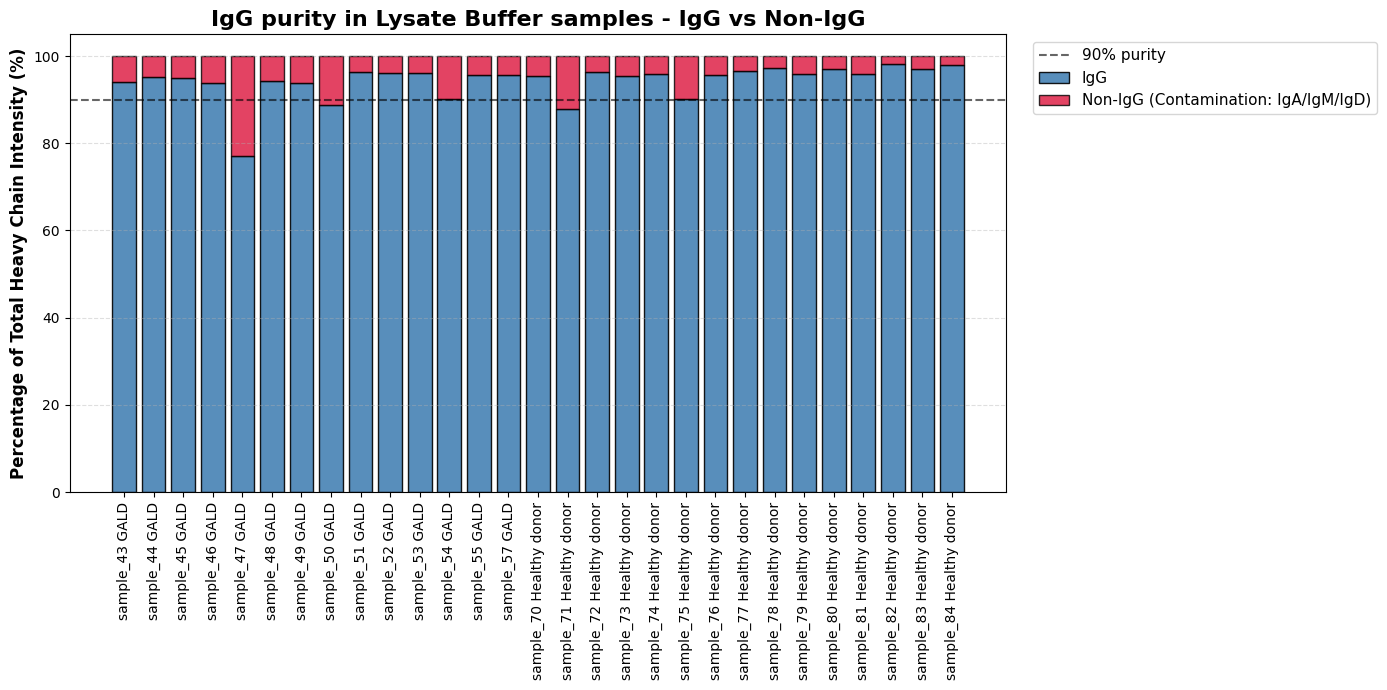

=== Summary Table of IP Purity ===


Ig_Class,Sample_Name,% IgG,% Non-IgG
0,sample_43 GALD,93.97,6.03
1,sample_44 GALD,95.21,4.79
2,sample_45 GALD,94.88,5.12
3,sample_46 GALD,93.88,6.12
4,sample_47 GALD,77.15,22.85
5,sample_48 GALD,94.27,5.73
6,sample_49 GALD,93.85,6.15
7,sample_50 GALD,88.77,11.23
8,sample_51 GALD,96.46,3.54
9,sample_52 GALD,96.20,3.80


In [7]:
# Getting the IgG to non-IgG ratio with clean sample aliases: 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

print("--- Calculating IgG Purity and Plotting Data ---")

# ==========================================
# 1. LOAD THE ANNOTATION MAPPING
# ==========================================
annot_df = pd.read_csv('../annotation_folder/experiment_annotation_run6_R1344.tsv', sep='\t') 
annot_df['sample_clean'] = annot_df['sample'].astype(str).str.strip() 
annot_df['condition_clean'] = annot_df['condition'].astype(str).str.strip() 

# Create the new alias: Sample Name + " " + Cohort (e.g., "sample_1 GALD")
annot_df['alias'] = annot_df['sample_clean'] + ' ' + annot_df['condition_clean']

# Create a mapping dictionary and extract the exact order of samples from the TSV
sample_to_alias = dict(zip(annot_df['sample_clean'], annot_df['alias']))
ordered_samples_all = annot_df['alias'].tolist()

# ==========================================
# 2. FILTER & PREP THE MASTER DF
# ==========================================
# 1. Define your target lists
IgG_peptides = ['IGHG1', 'IGHG2', 'IGHG3', 'IGHG4']
non_IgG_peptides = ['IGHA1', 'IGHA2', 'IGHM', 'IGHD']

# 2. Subset showing the protein-level intensity of immunoglobulins
df = master_prot_df[master_prot_df['Gene'].str.contains('IGHG|IGHA|IGHM|IGHD', case=False, na=False)].copy()

# Rename the sample column using our mapping dictionary
df['Sample_Name'] = df['Sample'].map(sample_to_alias).fillna(df['Sample'])

# Filter our ordered list to only include samples actually present in this subset
samples_present = df['Sample_Name'].unique()
ordered_samples = [s for s in ordered_samples_all if s in samples_present]

# ==========================================
# 3. CLASSIFICATION & AGGREGATION
# ==========================================
# Helper function to classify each row based on the Gene name
def classify_ig(gene_val):
    if pd.isna(gene_val):
        return 'Other'
    gene_clean = str(gene_val).split(';')[0]
    
    if gene_clean in IgG_peptides:
        return 'IgG'
    elif gene_clean in non_IgG_peptides:
        return 'Non-IgG'
    else:
        return 'Other'

# Apply the classification
df['Ig_Class'] = df['Gene'].apply(classify_ig)

# Filter out 'Other' proteins
hc_df = df[df['Ig_Class'] != 'Other']

# Aggregate the Razor Intensities per mapped Sample_Name
agg_df = hc_df.groupby(['Sample_Name', 'Ig_Class'])['Razor Intensity'].sum().reset_index()

# Pivot the table
pivot_df = agg_df.pivot(
    index='Sample_Name', 
    columns='Ig_Class', 
    values='Razor Intensity'
).fillna(0).reset_index()

# ==========================================
# 4. MATH & PERCENTAGES
# ==========================================
pivot_df['Total_Heavy_Chain'] = pivot_df['IgG'] + pivot_df['Non-IgG']

pivot_df['% IgG'] = np.where(
    pivot_df['Total_Heavy_Chain'] > 0, 
    (pivot_df['IgG'] / pivot_df['Total_Heavy_Chain']) * 100, 
    0
)
pivot_df['% Non-IgG'] = np.where(
    pivot_df['Total_Heavy_Chain'] > 0, 
    (pivot_df['Non-IgG'] / pivot_df['Total_Heavy_Chain']) * 100, 
    0
)

# Convert Sample_Name to a categorical type based on TSV order to lock the sorting
pivot_df['Sample_Name'] = pd.Categorical(pivot_df['Sample_Name'], categories=ordered_samples, ordered=True)
pivot_df = pivot_df.sort_values('Sample_Name')

# ==========================================
# 5. PLOT THE STACKED BAR CHART
# ==========================================
plt.figure(figsize=(14, 7))

x_positions = np.arange(len(pivot_df))
samples_plot = pivot_df['Sample_Name'].values
igg_vals = pivot_df['% IgG'].values
non_igg_vals = pivot_df['% Non-IgG'].values

# Create the stacked bars
plt.bar(x_positions, igg_vals, label='IgG', color='steelblue', edgecolor='black', alpha=0.9)
plt.bar(x_positions, non_igg_vals, bottom=igg_vals, label='Non-IgG (Contamination: IgA/IgM/IgD)', color='crimson', edgecolor='black', alpha=0.8)

# Add a 90% purity line
plt.axhline(y=90, color='black', linestyle='--', alpha=0.6, label='90% purity')

# Formatting the plot
plt.xticks(x_positions, samples_plot, rotation=90, fontsize=10)
plt.ylabel('Percentage of Total Heavy Chain Intensity (%)', fontsize=12, weight='bold')
plt.title('IgG purity in Lysate Buffer samples - IgG vs Non-IgG', fontsize=16, weight='bold')

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

# ==========================================
# 6. DISPLAY RAW MATH TABLE
# ==========================================
print("=== Summary Table of IP Purity ===")
# Reorder columns for clean display
display_df = pivot_df[['Sample_Name', '% IgG', '% Non-IgG']].round(2).reset_index(drop=True)
display(display_df)

In [ ]:
#Getting the Aitchison mean (aka. geometric mean) of the Non-IgG to IgG: 
#(When working with compositional values, you need to take the Aitchison mean) 

from scipy.stats import gmean #Geometric mean

# 1. Add a tiny pseudocount to avoid log(0) errors in geometric means
# We use a small fraction of the minimum non-zero intensity in the dataset
#pseudo = pivot_df[['IgG', 'Non-IgG']].replace(0, np.nan).min().min() * 0.01

igg_safe = pivot_df['IgG'] # + pseudo
non_igg_safe = pivot_df['Non-IgG'] # + pseudo

# 2. Calculate the Geometric Mean of the raw intensities
geom_mean_igg = gmean(igg_safe)
geom_mean_non_igg = gmean(non_igg_safe)

# 3. "Close" the composition (normalize them so they sum to 100%)
total_geom = geom_mean_igg + geom_mean_non_igg
avg_percent_igg = (geom_mean_igg / total_geom) * 100
avg_percent_non_igg = (geom_mean_non_igg / total_geom) * 100

print(f"=== Compositional Average (Aitchison Mean) ===")
print(f"Overall Average IgG Purity:     {avg_percent_igg:.2f}%")
print(f"Overall Average Non-IgG Contam: {avg_percent_non_igg:.2f}%")
print(f"Average Ratio (IgG : Non-IgG):  {geom_mean_igg/geom_mean_non_igg:.1f} : 1")


=== Compositional Average (Aitchison Mean) ===
Overall Average IgG Purity:     95.14%
Overall Average Non-IgG Contam: 4.86%
Average Ratio (IgG : Non-IgG):  19.6 : 1


## **Part 1 - N-linked glycosylation:**

In [9]:
#Getting the N-linked glycosylation peptides: 

#Only the glycosylated peptides:
psm_glycosylation_df = master_psm_df[master_psm_df["Total Glycan Composition"].notna()].sort_values("Gene").copy() 
#Note, it is nice sorting it to gene names, 
#so we can view the glycosylated peptides in a more organized way.


#Getting only the glycosylated peptides that are from immunoglobulins: 
antibody_pep_glyco_df = psm_glycosylation_df[psm_glycosylation_df["Protein Description"].str.contains("immunoglobulin", case=False, na=False)].copy()

display(antibody_pep_glyco_df.head(3))
#Be sure to check the 'Total Glycan Composition' column. 

,Sample,Group,Sample_type,Peptide,Modified Peptide,Gene,Protein,Protein Description,Total Glycan Composition,Assigned Modifications,Intensity,Probability
119551,sample_74,Healthy donor,Lysate buffer,LSLHRPALEDLLLGSEANLTCTLTGLR,LSLHRPALEDLLLGSEAN[2028]LTCTLTGLR,IGHA1,sp|P01876|IGHA1_HUMAN,Immunoglobulin heavy constant alpha 1,HexNAc(4)Hex(5)NeuAc(1) % 1913.6770,"18N(1913.6770),21C(57.0215)",42171.816,0.8598
75739,sample_53,GALD,Lysate buffer,LSLHRPALEDLLLGSEANLTCTLTGLR,LSLHRPALEDLLLGSEAN[2028]LTCTLTGLR,IGHA1,sp|P01876|IGHA1_HUMAN,Immunoglobulin heavy constant alpha 1,HexNAc(4)Hex(5)NeuAc(1) % 1913.6770,"18N(1913.6770),21C(57.0215)",224048.030,0.9169
69093,sample_52,GALD,Lysate buffer,LSLHRPALEDLLLGSEANLTCTLTGLR,LSLHRPALEDLLLGSEAN[2028]LTCTLTGLR,IGHA1,sp|P01876|IGHA1_HUMAN,Immunoglobulin heavy constant alpha 1,HexNAc(4)Hex(5)NeuAc(1) % 1913.6770,"18N(1913.6770),21C(57.0215)",228527.020,0.9835


In [10]:
#Quick check - Making peptide count tables: 

#Counting - The amount of glycosylated peptides for each immunoglobulin gene: 
print("Number of glycosylated peptides for each immunoglobulin gene:") 
display( pd.DataFrame(antibody_pep_glyco_df.value_counts("Gene")) ) 

#Counting - The amount of glycosylated peptides for each sample: 
print("Number of glycosylated peptides for each sample:") 
temp_df = pd.DataFrame(antibody_pep_glyco_df.value_counts("Sample")) 
display(temp_df.reindex(sorted(temp_df.index, key=lambda x: int(x.split('_')[-1])))) 

#Coverage in the entire dataset
print("Coverage of any peptides in the entire dataset:")
temp_df = pd.DataFrame(master_pep_df.value_counts("Sample"))
display(temp_df.reindex(sorted(temp_df.index, key=lambda x: int(x.split('_')[-1]))))


Number of glycosylated peptides for each immunoglobulin gene:


,count
Gene,
IGHG3,39
IGHA1,16
IGHG2,9
IGHG1,4


Number of glycosylated peptides for each sample:


,count
Sample,
sample_43,4
sample_44,5
sample_45,1
sample_46,1
sample_47,2
sample_49,1
sample_50,6
sample_51,11
sample_52,3


Coverage of any peptides in the entire dataset:


,count
Sample,
sample_43,2736
sample_44,2273
sample_45,3419
sample_46,2996
sample_47,3715
sample_48,2303
sample_49,2215
sample_50,3468
sample_51,1863


**Reminder**: sample 43-55 and 57 are GALD mother. <br>
sample 70 to 84 is healthy mothers. 

**Important note**: Upon inspection it was revealed that the type of glycosylation is not only from the same peptide, but from 2 entirely different peptides <br>
One in the CH2 region and another one in the CH3 region of IgG. 

--- Generating Site-Specific Glycosylated Immunoglobulin Heatmap & Summary ---


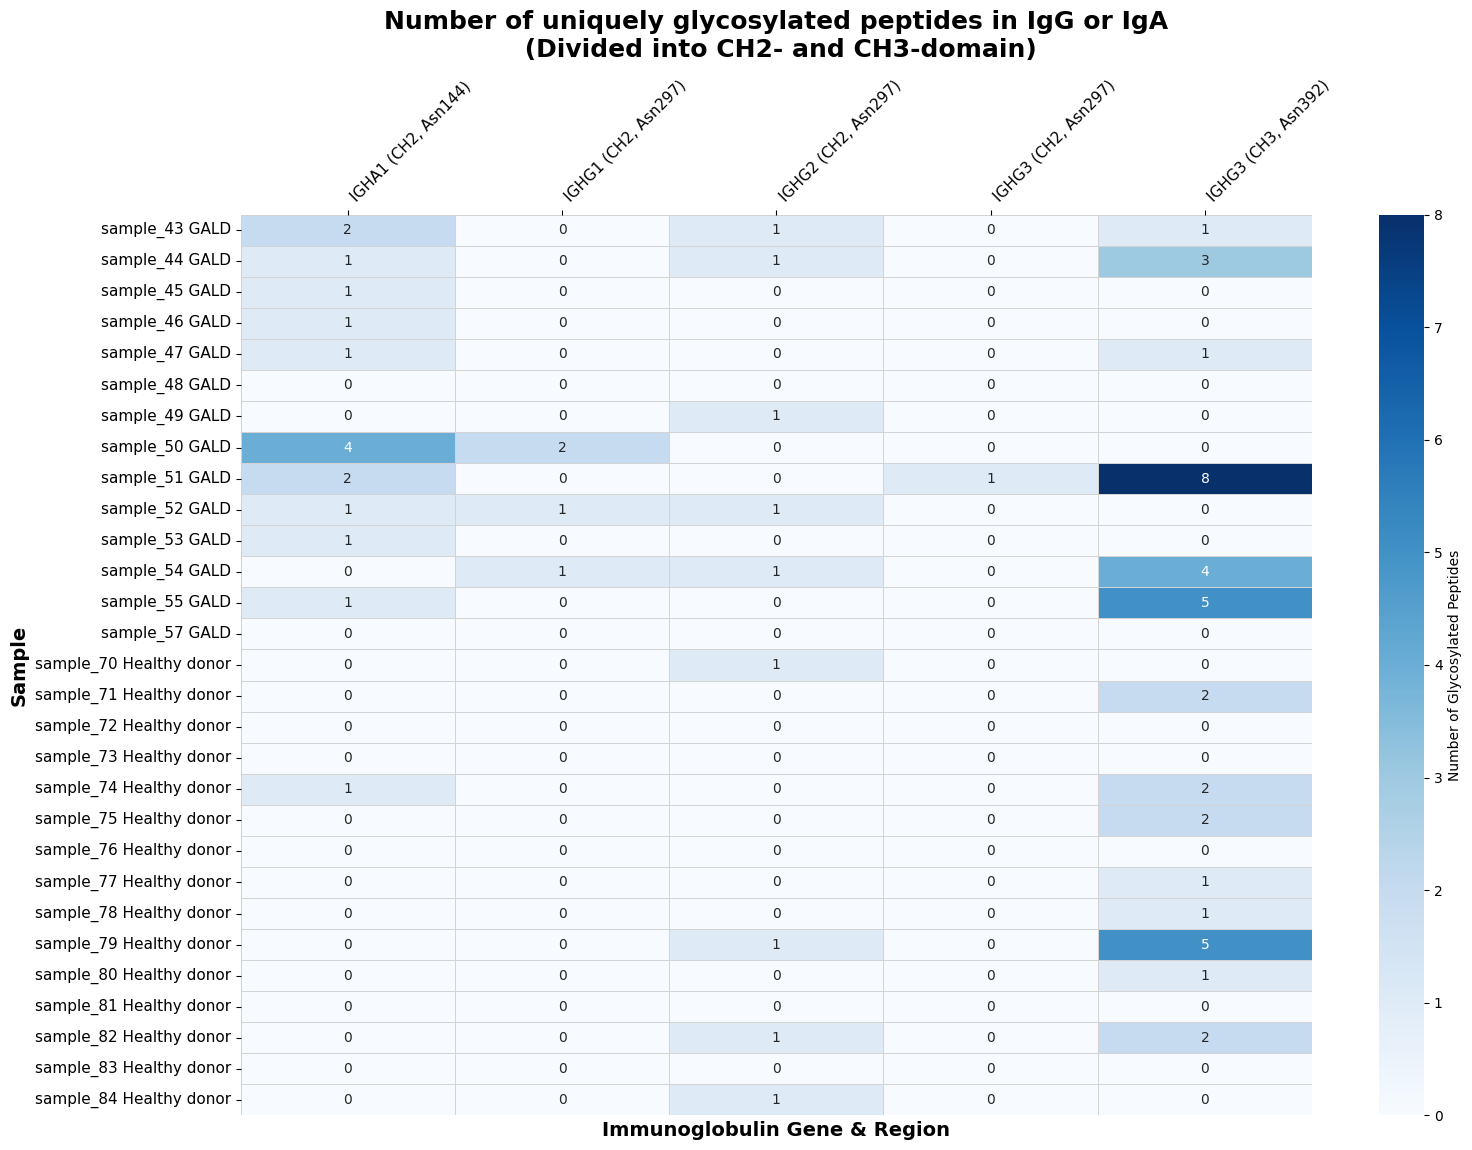


--- Overall Sample Coverage Summary ---


,Total_Immunoglobulin_Glycosylated_Peptides,Total_Immunoglobulin_Peptides_Identified,% Glycosylated
Sample_Name,,,
sample_43 GALD,4,674,0.59
sample_44 GALD,5,664,0.75
sample_45 GALD,1,689,0.15
sample_46 GALD,1,682,0.15
sample_47 GALD,2,624,0.32
sample_48 GALD,0,666,0.00
sample_49 GALD,1,661,0.15
sample_50 GALD,6,677,0.89
sample_51 GALD,11,676,1.63


In [11]:
#Heat map of number of uniquely glycosylated antibody peptides. 

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("--- Generating Site-Specific Glycosylated Immunoglobulin Heatmap & Summary ---")

# ==========================================
# 1. LOAD THE ANNOTATION MAPPING
# ==========================================
annot_df = pd.read_csv('../annotation_folder/experiment_annotation_run6_R1344.tsv', sep='\t') 
annot_df['sample_clean'] = annot_df['sample'].astype(str).str.strip() 
annot_df['condition_clean'] = annot_df['condition'].astype(str).str.strip() 

# Create the new alias: Cohort + " " + Sample Name (e.g., "GALD sample_1")
#annot_df['alias'] = annot_df['condition_clean'] + ' ' + annot_df['sample_clean']
annot_df['alias'] = annot_df['sample_clean'] + ' ' + annot_df['condition_clean']

# Create a mapping dictionary and extract the exact order of samples from the TSV
sample_to_alias = dict(zip(annot_df['sample_clean'], annot_df['alias']))
ordered_samples = annot_df['alias'].tolist()

# ==========================================
# 2. RENAME SAMPLES IN DATAFRAMES
# ==========================================
# We create a new column 'Sample_Name' to preserve the original raw data
antibody_pep_glyco_df = antibody_pep_glyco_df.copy() # Safe copy
antibody_pep_glyco_df['Sample_Name'] = antibody_pep_glyco_df['Sample'].map(sample_to_alias).fillna(antibody_pep_glyco_df['Sample'])

master_pep_df = master_pep_df.copy() # Safe copy
master_pep_df['Sample_Name'] = master_pep_df['Sample'].map(sample_to_alias).fillna(master_pep_df['Sample'])

# Filter our ordered list to only include samples actually present in master_pep_df
master_samples_present = master_pep_df['Sample_Name'].unique()
ordered_samples = [s for s in ordered_samples if s in master_samples_present]

# ==========================================
# 3. SITE-SPECIFIC MAPPING LOGIC
# ==========================================
# We define a function to map the gene + peptide sequence to a specific biological site

#I.e. is the peptide from the CH2 domain or the CH3 domain of the antibody. 


def assign_glyco_site(row):
    gene = str(row.get('Gene', ''))
    peptide = str(row.get('Peptide', '')) # FragPipe usually stores sequence in 'Peptide'
    
    # We use 'in' to catch the core sequence, ignoring cleavage site parentheses if present
    if gene == 'IGHA1' and 'LSLHRP' in peptide:
        return 'IGHA1 (CH2, Asn144)'
    elif gene == 'IGHG1' and 'EEQYNSTYR' in peptide:
        return 'IGHG1 (CH2, Asn297)'
    elif gene == 'IGHG2' and 'EEQFNSTFR' in peptide:
        return 'IGHG2 (CH2, Asn297)'
    elif gene == 'IGHG3' and 'EEQYNSTFR' in peptide:
        return 'IGHG3 (CH2, Asn297)'
    elif gene == 'IGHG3' and 'GFYPSD' in peptide:
        return 'IGHG3 (CH3, Asn392)'
    elif gene == 'IGHM':
        return 'IGHM (Other)'
    elif gene == 'IGHD':
        return 'IGHD (Other)'
    else:
        # Fallback just in case a rare peptide slips through
        return f"{gene} (Other)"

# Apply the mapping to create a new column for the heatmap
antibody_pep_glyco_df['Gene_Site'] = antibody_pep_glyco_df.apply(assign_glyco_site, axis=1)

# ==========================================
# 4. GENERATE HEATMAP MATRIX (WITH ZERO-FILLING)
# ==========================================
# Pivot using our new 'Gene_Site' column instead of just 'Gene'
glyco_matrix = antibody_pep_glyco_df.pivot_table(
    index='Sample_Name', 
    columns='Gene_Site', 
    aggfunc='size', 
    fill_value=0
)

# REINDEX: Force samples with 0 glycopeptides to appear in the matrix
glyco_matrix = glyco_matrix.reindex(ordered_samples, fill_value=0)

# Sort the columns alphabetically so CH2 and CH3 appear next to each other
glyco_matrix = glyco_matrix.reindex(sorted(glyco_matrix.columns), axis=1)

# ==========================================
# 5. PLOT HEATMAP
# ==========================================
plt.figure(figsize=(16, max(6, len(glyco_matrix) * 0.4)))

sns.heatmap(
    glyco_matrix, 
    cmap='Blues', 
    annot=True, 
    fmt='g', 
    linewidths=0.5, 
    linecolor='lightgray',
    cbar_kws={'label': 'Number of Glycosylated Peptides'}
)

plt.title('Number of uniquely glycosylated peptides in IgG or IgA\n (Divided into CH2- and CH3-domain)', fontsize=18, weight='bold', pad=15)
plt.ylabel('Sample', fontsize=14, weight='bold')
plt.xlabel('Immunoglobulin Gene & Region', fontsize=14, weight='bold')
plt.tick_params(axis='x', bottom=False, top=True, labelbottom=False, labeltop=True)
plt.xticks(rotation=45, ha='left', fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

# ==========================================
# 6. GENERATE SUMMARY TABLE
# ==========================================
glyco_counts = antibody_pep_glyco_df['Sample_Name'].value_counts().rename('Total_Immunoglobulin_Glycosylated_Peptides')

# Count biologically relevant peptides
total_counts = master_pep_df[master_pep_df["Protein Description"].str.contains("immunoglobulin", case=False, na=False)]['Sample_Name'].value_counts().rename('Total_Immunoglobulin_Peptides_Identified')

# Combine and REINDEX to ensure 0-count samples are included
coverage_summary_df = pd.concat([glyco_counts, total_counts], axis=1)
coverage_summary_df = coverage_summary_df.reindex(ordered_samples).fillna(0).astype(int)

# Calculate Percentage
coverage_summary_df['% Glycosylated'] = (
    (coverage_summary_df['Total_Immunoglobulin_Glycosylated_Peptides'] / coverage_summary_df['Total_Immunoglobulin_Peptides_Identified']) * 100
).round(2).fillna(0)

print("\n--- Overall Sample Coverage Summary ---")
display(coverage_summary_df)


In [12]:
#How many many samples did not have any glycosylated immunoglobulin peptides?

#Total: 
print("Total:", coverage_summary_df[coverage_summary_df["Total_Immunoglobulin_Glycosylated_Peptides"] == 0].shape[0])

#Healthy: 
print("Healthy:", coverage_summary_df[(coverage_summary_df["Total_Immunoglobulin_Glycosylated_Peptides"] == 0) & (coverage_summary_df.index.str.contains("Healthy", case=False, na=False))].shape[0])

#GALD: 
print("GALD:", coverage_summary_df[(coverage_summary_df["Total_Immunoglobulin_Glycosylated_Peptides"] == 0) & (coverage_summary_df.index.str.contains("GALD", case=False, na=False))].shape[0])

Total: 7
Healthy: 5
GALD: 2


#### **Scatterplot for the %-glycosylation values:**

In [14]:
#Making a dataframe for only the glycosylated peptides from immunoglobulins: 
antibody_pep_glyco_df = psm_glycosylation_df[psm_glycosylation_df["Protein Description"].str.contains("immunoglobulin", case=False, na=False)].copy() 
IgG_pep_glyco_df = antibody_pep_glyco_df[antibody_pep_glyco_df["Gene"] != "IGHA1"].copy() #Exclude IgA1! 

display(IgG_pep_glyco_df.sample(3))

,Sample,Group,Sample_type,Peptide,Modified Peptide,Gene,Protein,Protein Description,Total Glycan Composition,Assigned Modifications,Intensity,Probability
83481,sample_54,GALD,Lysate buffer,GFYPSDIAVEWESSGQPENNYNTTPPMLDSDGSFFLYSK,GFYPSDIAVEWESSGQPENNYN[1987]TTPPMLDSDGSFFLYSK,IGHG3,sp|P01860|IGHG3_HUMAN,Immunoglobulin heavy constant gamma 3,HexNAc(3)Hex(6)NeuAc(1) % 1872.6505,22N(1872.6505),28639.451,1.000
76337,sample_54,GALD,Lysate buffer,EEQYNSTYR,EEQYN[1721]STYR,IGHG1,sp|P01857|IGHG1_HUMAN,Immunoglobulin heavy constant gamma 1,HexNAc(4)Hex(4)Fuc(1) % 1606.5867,5N(1606.5867),102367.445,0.955
104789,sample_71,Healthy donor,Lysate buffer,GFYPSDIAVEWESSGQPENNYNTTPPMLDSDGSFFLYSK,GFYPSDIAVEWESSGQPENNYN[1778]TTPPMLDSDGSFFLYSK,IGHG3,sp|P01860|IGHG3_HUMAN,Immunoglobulin heavy constant gamma 3,HexNAc(5)Hex(4) % 1663.6081,22N(1663.6082),30269.508,1.000


We want to make a scatter plot that plots the % prevalence of the 4 macro traits for glycans in IgG. We only focus on the CH2 domain for now. <br>
<br>
Since we want to plot the geometric mean, we can't include 0 values, or the geometric mean would become 0.<br>
In other words, we either have to move the 0 values entirely, but this would make the geometric mean skyrocket, and would be misleading. <br>
<br>
Instead, we can impute by adding the pseudocount.<br>
However, we don't want to pick the pseudocount based on the local minimum value - since if that is e.g. 100% (apart from the 0% values), then the pseudocount would become 50%. <br>
Instead, we find the global minimum intensity of a glycosylated peptide in the dataset (assumed to be the detection limit) and calculate the % that this intensity would lead to. <br>
We use add this pseudocount value to all intensities and calculate the geometric mean, even though that might inflate it a bit. <br>
When we actually plot the % values, we don't want to use the pseudocounts but the actual 0% values, etc. <br>
<br>
Long story short: The geometric mean at 0, is technically not possible, but is there for illustration purposes. 

--- Glycoproteomic Dashboard: CH2 Macro Traits (Raw Scatter + Imputed GeoMean) ---
Extracting monosaccharide counts...
Calculating Global Intensity Pseudocount...
 -> Global Detection Limit (LOD) Pseudocount: 2111.26
Calculating Raw and Imputed Macro Trait Percentages...
Generating Plot...


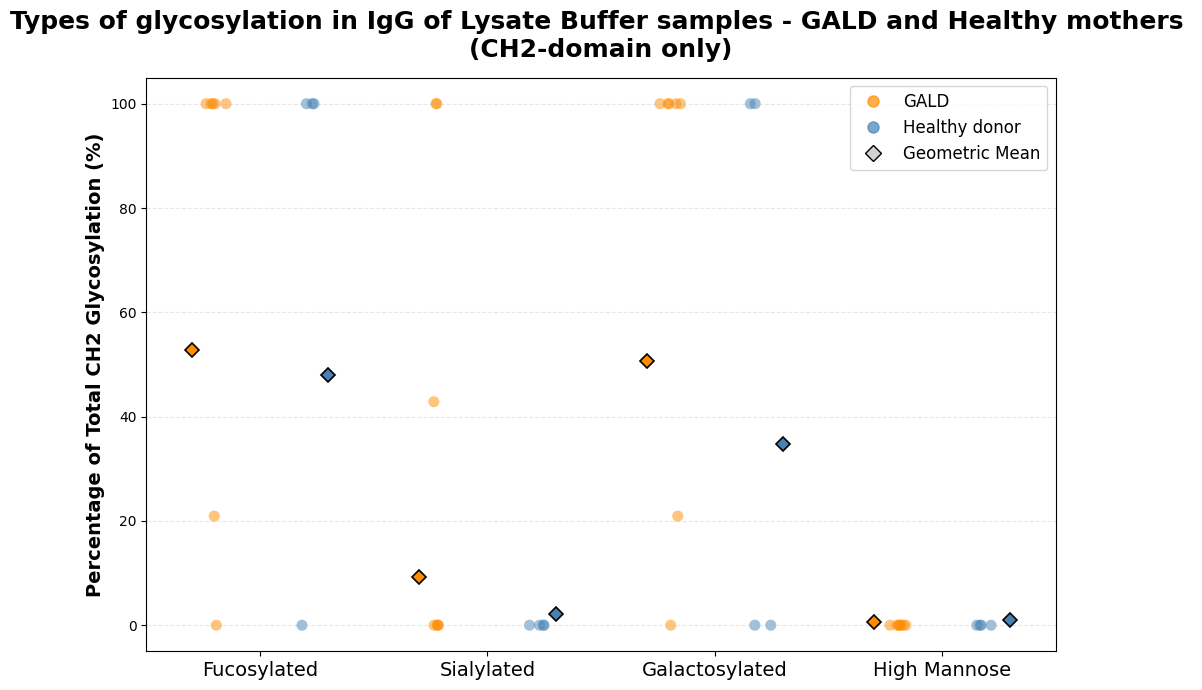

In [ ]:
#CH2 scatterplot
#Making a scatterplot of the glycosylated CH2 peptides 
#Pseudocounts are used to find the geometric mean. 

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines

print("--- Glycoproteomic Dashboard: CH2 Macro Traits (Raw Scatter + Imputed GeoMean) ---")

# ==========================================
# 1. PARSE SUGAR COUNTS & MACRO TRAITS
# ==========================================
antibody_pep_glyco_df = psm_glycosylation_df[psm_glycosylation_df["Protein Description"].str.contains("immunoglobulin", case=False, na=False)].copy() 
IgG_pep_glyco_df = antibody_pep_glyco_df[antibody_pep_glyco_df["Gene"] != "IGHA1"].copy()

glyco_df = IgG_pep_glyco_df.copy()

def extract_sugar(composition, sugar_name):
    match = re.search(rf'{sugar_name}\((\d+)\)', str(composition))
    return int(match.group(1)) if match else 0

print("Extracting monosaccharide counts...")
glyco_df['HexNAc'] = glyco_df['Total Glycan Composition'].apply(lambda x: extract_sugar(x, 'HexNAc'))
glyco_df['Hex'] = glyco_df['Total Glycan Composition'].apply(lambda x: extract_sugar(x, 'Hex'))
glyco_df['Fuc'] = glyco_df['Total Glycan Composition'].apply(lambda x: extract_sugar(x, 'Fuc'))
glyco_df['NeuAc'] = glyco_df['Total Glycan Composition'].apply(lambda x: extract_sugar(x, 'NeuAc'))

def is_fuc(comp): return extract_sugar(comp, 'Fuc') > 0
def is_sia(comp): return extract_sugar(comp, 'NeuAc') > 0
def is_gal(comp): return extract_sugar(comp, 'HexNAc') >= 3 and extract_sugar(comp, 'Hex') >= 4
def is_hm(comp): return extract_sugar(comp, 'HexNAc') == 2 and extract_sugar(comp, 'Hex') >= 5

def assign_region(peptide):
    pep = str(peptide).upper()
    if 'EEQ' in pep: return 'CH2'
    elif 'GFY' in pep: return 'CH3'
    else: return 'Other'

glyco_df['Region'] = glyco_df['Peptide'].apply(assign_region)

ch2_df = glyco_df[glyco_df['Region'] == 'CH2'].copy()

# ==========================================
# 2. GLOBAL INTENSITY IMPUTATION SETUP
# ==========================================
print("Calculating Global Intensity Pseudocount...")
min_global_int = psm_glycosylation_df.loc[psm_glycosylation_df['Intensity'] > 0, 'Intensity'].min()
lod_intensity = min_global_int / 2

print(f" -> Global Detection Limit (LOD) Pseudocount: {lod_intensity:.2f}")

pivot_raw = ch2_df.pivot_table(index=['Sample', 'Group'], columns='Total Glycan Composition', values='Intensity', aggfunc='sum').fillna(0)
pivot_imputed = pivot_raw + lod_intensity

# ==========================================
# 3. CALCULATE % FOR BOTH MATRICES
# ==========================================
print("Calculating Raw and Imputed Macro Trait Percentages...")

raw_macro_data = []
imputed_macro_data = []

for (sample, group) in pivot_raw.index:
    row_raw = pivot_raw.loc[(sample, group)]
    row_imp = pivot_imputed.loc[(sample, group)]
    
    total_raw = row_raw.sum()
    total_imp = row_imp.sum()
    
    if total_raw > 0:
        dict_raw = {'Sample': sample, 'Group': group}
        dict_imp = {'Sample': sample, 'Group': group}
        
        traits_to_check = [('Fucosylated', is_fuc), ('Sialylated', is_sia), ('Galactosylated', is_gal), ('High_Mannose', is_hm)]
        
        for trait_name, func in traits_to_check:
            trait_cols = [c for c in pivot_raw.columns if func(c)]
            
            # 1. Raw Percentage (Can safely be 0% if trait_cols is empty)
            if len(trait_cols) > 0:
                raw_trait_sum = row_raw[trait_cols].sum()
            else:
                raw_trait_sum = 0.0
                
            dict_raw[f'%_{trait_name}'] = (raw_trait_sum / total_raw) * 100
            
            # 2. Imputed Percentage (Safety catch applied!)
            if len(trait_cols) > 0:
                imp_trait_sum = row_imp[trait_cols].sum()
            else:
                # If the trait never existed in the run, assume 1 undetected glycan sitting at LOD
                imp_trait_sum = lod_intensity 
                
            dict_imp[f'%_{trait_name}'] = (imp_trait_sum / total_imp) * 100
            
        raw_macro_data.append(dict_raw)
        imputed_macro_data.append(dict_imp)

df_raw_macro = pd.DataFrame(raw_macro_data).set_index(['Sample', 'Group'])
df_imp_macro = pd.DataFrame(imputed_macro_data).set_index(['Sample', 'Group'])

macro_labels = {'%_Fucosylated': 'Fucosylated', '%_Sialylated': 'Sialylated', 
                '%_Galactosylated': 'Galactosylated', '%_High_Mannose': 'High Mannose'}

# ==========================================
# 4. STRICT GEOMETRIC MEAN FUNCTION
# ==========================================
def simple_gmean(x):
    """Calculates geometric mean directly. The input data is guaranteed strictly > 0."""
    return np.exp(np.mean(np.log(x)))

# ==========================================
# 5. VISUALIZATION
# ==========================================
print("Generating Plot...")

plot_raw_df = df_raw_macro.reset_index().melt(id_vars=['Sample', 'Group'], var_name='Trait', value_name='Percentage (%)')
plot_raw_df['Label'] = plot_raw_df['Trait'].map(macro_labels)

plot_imp_df = df_imp_macro.reset_index().melt(id_vars=['Sample', 'Group'], var_name='Trait', value_name='Percentage (%)')
plot_imp_df['Label'] = plot_imp_df['Trait'].map(macro_labels)

ordered_macro_labels = [macro_labels[t] for t in ['%_Fucosylated', '%_Sialylated', '%_Galactosylated', '%_High_Mannose']]
scatter_palette = {'GALD': 'darkorange', 'Healthy donor': 'steelblue'}
custom_legend_elements = [
    mlines.Line2D([], [], color='darkorange', marker='o', linestyle='None', markersize=8, alpha=0.7, label='GALD'),
    mlines.Line2D([], [], color='steelblue', marker='o', linestyle='None', markersize=8, alpha=0.7, label='Healthy donor'),
    mlines.Line2D([], [], color='lightgray', markeredgecolor='black', marker='D', linestyle='None', markersize=8, label='Geometric Mean')
]

plt.figure(figsize=(10, 7))

# 1. DRAW RAW DATA
sns.stripplot(
    data=plot_raw_df, x='Label', y='Percentage (%)', hue='Group', 
    palette=scatter_palette, order=ordered_macro_labels, 
    dodge=True, alpha=0.5, size=8, jitter=True, zorder=1
)

# 2. DRAW IMPUTED GEOMETRIC MEAN
sns.pointplot(
    data=plot_imp_df, x='Label', y='Percentage (%)', hue='Group', 
    estimator=simple_gmean, errorbar=None, order=ordered_macro_labels,
    palette=scatter_palette, dodge=0.6, markers="D", linestyles="", 
    zorder=2, markeredgecolor='black', markeredgewidth=1.2
)

plt.title("Types of glycosylation in IgG of Lysate Buffer samples - GALD and Healthy mothers \n(CH2-domain only)", fontsize=18, weight='bold', pad=15)
plt.ylabel("Percentage of Total CH2 Glycosylation (%)", fontsize=14, weight='bold')
plt.xlabel("")
plt.tick_params(axis='x', labelsize=14)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.legend(handles=custom_legend_elements, loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()


**Note**: There are only 4 glycosylated peptides from the CH2 domain in healthy mother samples, and only were discovered for 7 of the GALD mother samples. <br>
That is simply because no detection of ANY type of CH2 IgG glycosylation in majority of the healthy mothers was found. 

In [36]:
#Diagnostic check - the 4 healthy mothers with CH2 glycosylation

print("--- Diagnostic: Where are the Healthy Donors? ---")

# 1. Check total samples vs CH2 samples
total_samples = glyco_df.groupby('Group')['Sample'].nunique()
ch2_samples = ch2_df.groupby('Group')['Sample'].nunique()

print("\n1. Total Samples with ANY glyocosylated IgG peptides detected:")
print(total_samples.to_string())

print("\n2. Total Samples with glycosylated CH2 ('EEQ') peptides detected:")
print(ch2_samples.to_string())

# 3. Print the exact percentages for Healthy Donors in CH2
if 'Healthy donor' in df_raw_macro.index.get_level_values('Group'):
    healthy_gal = df_raw_macro.xs('Healthy donor', level='Group')['%_Galactosylated']
    print(f"\n3. Exact Galactosylation % for Healthy Donors ({len(healthy_gal)} found):")
    print(healthy_gal.sort_values(ascending=False).to_string())
else:
    print("\n3. ERROR: No Healthy donors found in the CH2 macro data!")

--- Diagnostic: Where are the Healthy Donors? ---

1. Total Samples with ANY glyocosylated IgG peptides detected:
Group
GALD              9
Healthy donor    10

2. Total Samples with glycosylated CH2 ('EEQ') peptides detected:
Group
GALD             7
Healthy donor    4

3. Exact Galactosylation % for Healthy Donors (4 found):
Sample
sample_84    100.0
sample_82    100.0
sample_79      0.0
sample_70      0.0


--- Glycoproteomic Dashboard: CH3 Macro Traits (Raw Scatter + Imputed GeoMean) ---
Extracting monosaccharide counts...
Calculating Global Intensity Pseudocount...
 -> Global Detection Limit (LOD) Pseudocount: 2111.26
Calculating Raw and Imputed Macro Trait Percentages...
Generating Plot...


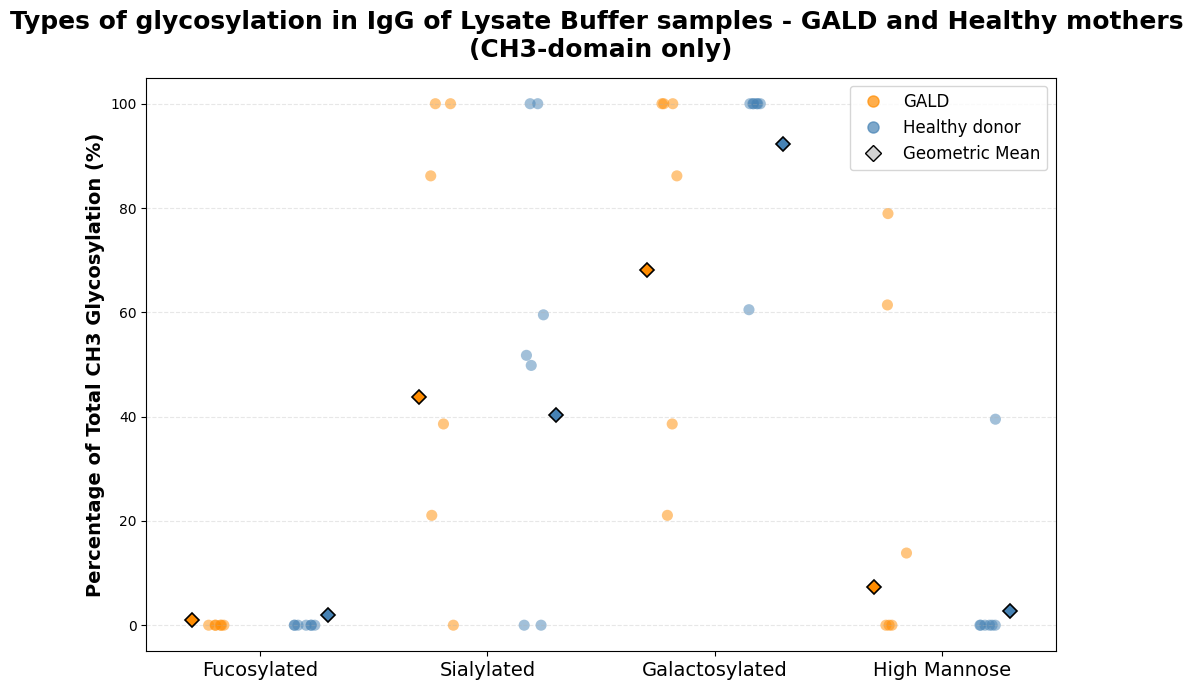

In [ ]:
#CH3 scatterplot
#Making a scatterplot of the glycosylated CH3 peptides 
#Pseudocounts are used to find the geometric mean. 

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines

print("--- Glycoproteomic Dashboard: CH3 Macro Traits (Raw Scatter + Imputed GeoMean) ---")

# ==========================================
# 1. PARSE SUGAR COUNTS & MACRO TRAITS
# ==========================================
antibody_pep_glyco_df = psm_glycosylation_df[psm_glycosylation_df["Protein Description"].str.contains("immunoglobulin", case=False, na=False)].copy() 
IgG_pep_glyco_df = antibody_pep_glyco_df[antibody_pep_glyco_df["Gene"] != "IGHA1"].copy()

glyco_df = IgG_pep_glyco_df.copy()

def extract_sugar(composition, sugar_name):
    match = re.search(rf'{sugar_name}\((\d+)\)', str(composition))
    return int(match.group(1)) if match else 0

print("Extracting monosaccharide counts...")
glyco_df['HexNAc'] = glyco_df['Total Glycan Composition'].apply(lambda x: extract_sugar(x, 'HexNAc'))
glyco_df['Hex'] = glyco_df['Total Glycan Composition'].apply(lambda x: extract_sugar(x, 'Hex'))
glyco_df['Fuc'] = glyco_df['Total Glycan Composition'].apply(lambda x: extract_sugar(x, 'Fuc'))
glyco_df['NeuAc'] = glyco_df['Total Glycan Composition'].apply(lambda x: extract_sugar(x, 'NeuAc'))

def is_fuc(comp): return extract_sugar(comp, 'Fuc') > 0
def is_sia(comp): return extract_sugar(comp, 'NeuAc') > 0
def is_gal(comp): return extract_sugar(comp, 'HexNAc') >= 3 and extract_sugar(comp, 'Hex') >= 4
def is_hm(comp): return extract_sugar(comp, 'HexNAc') == 2 and extract_sugar(comp, 'Hex') >= 5

def assign_region(peptide):
    pep = str(peptide).upper()
    if 'EEQ' in pep: return 'CH2'
    elif 'GFY' in pep: return 'CH3'
    else: return 'Other'

glyco_df['Region'] = glyco_df['Peptide'].apply(assign_region)

# --> ISOLATING CH3 REGION HERE <--
ch3_df = glyco_df[glyco_df['Region'] == 'CH3'].copy()

# ==========================================
# 2. GLOBAL INTENSITY IMPUTATION SETUP
# ==========================================
print("Calculating Global Intensity Pseudocount...")
min_global_int = psm_glycosylation_df.loc[psm_glycosylation_df['Intensity'] > 0, 'Intensity'].min()
lod_intensity = min_global_int / 2

print(f" -> Global Detection Limit (LOD) Pseudocount: {lod_intensity:.2f}")

pivot_raw = ch3_df.pivot_table(index=['Sample', 'Group'], columns='Total Glycan Composition', values='Intensity', aggfunc='sum').fillna(0)
pivot_imputed = pivot_raw + lod_intensity

# ==========================================
# 3. CALCULATE % FOR BOTH MATRICES
# ==========================================
print("Calculating Raw and Imputed Macro Trait Percentages...")

raw_macro_data = []
imputed_macro_data = []

for (sample, group) in pivot_raw.index:
    row_raw = pivot_raw.loc[(sample, group)]
    row_imp = pivot_imputed.loc[(sample, group)]
    
    total_raw = row_raw.sum()
    total_imp = row_imp.sum()
    
    if total_raw > 0:
        dict_raw = {'Sample': sample, 'Group': group}
        dict_imp = {'Sample': sample, 'Group': group}
        
        traits_to_check = [('Fucosylated', is_fuc), ('Sialylated', is_sia), ('Galactosylated', is_gal), ('High_Mannose', is_hm)]
        
        for trait_name, func in traits_to_check:
            trait_cols = [c for c in pivot_raw.columns if func(c)]
            
            # 1. Raw Percentage (Can safely be 0% if trait_cols is empty)
            if len(trait_cols) > 0:
                raw_trait_sum = row_raw[trait_cols].sum()
            else:
                raw_trait_sum = 0.0
                
            dict_raw[f'%_{trait_name}'] = (raw_trait_sum / total_raw) * 100
            
            # 2. Imputed Percentage (Safety catch applied!)
            if len(trait_cols) > 0:
                imp_trait_sum = row_imp[trait_cols].sum()
            else:
                # If the trait never existed in the run, assume 1 undetected glycan sitting at LOD
                imp_trait_sum = lod_intensity 
                
            dict_imp[f'%_{trait_name}'] = (imp_trait_sum / total_imp) * 100
            
        raw_macro_data.append(dict_raw)
        imputed_macro_data.append(dict_imp)

df_raw_macro = pd.DataFrame(raw_macro_data).set_index(['Sample', 'Group'])
df_imp_macro = pd.DataFrame(imputed_macro_data).set_index(['Sample', 'Group'])

macro_labels = {'%_Fucosylated': 'Fucosylated', '%_Sialylated': 'Sialylated', 
                '%_Galactosylated': 'Galactosylated', '%_High_Mannose': 'High Mannose'}

# ==========================================
# 4. STRICT GEOMETRIC MEAN FUNCTION
# ==========================================
def simple_gmean(x):
    """Calculates geometric mean directly. The input data is guaranteed strictly > 0."""
    return np.exp(np.mean(np.log(x)))

# ==========================================
# 5. VISUALIZATION
# ==========================================
print("Generating Plot...")

plot_raw_df = df_raw_macro.reset_index().melt(id_vars=['Sample', 'Group'], var_name='Trait', value_name='Percentage (%)')
plot_raw_df['Label'] = plot_raw_df['Trait'].map(macro_labels)

plot_imp_df = df_imp_macro.reset_index().melt(id_vars=['Sample', 'Group'], var_name='Trait', value_name='Percentage (%)')
plot_imp_df['Label'] = plot_imp_df['Trait'].map(macro_labels)

ordered_macro_labels = [macro_labels[t] for t in ['%_Fucosylated', '%_Sialylated', '%_Galactosylated', '%_High_Mannose']]
scatter_palette = {'GALD': 'darkorange', 'Healthy donor': 'steelblue'}
custom_legend_elements = [
    mlines.Line2D([], [], color='darkorange', marker='o', linestyle='None', markersize=8, alpha=0.7, label='GALD'),
    mlines.Line2D([], [], color='steelblue', marker='o', linestyle='None', markersize=8, alpha=0.7, label='Healthy donor'),
    mlines.Line2D([], [], color='lightgray', markeredgecolor='black', marker='D', linestyle='None', markersize=8, label='Geometric Mean')
]

plt.figure(figsize=(10, 7))

# 1. DRAW RAW DATA
sns.stripplot(
    data=plot_raw_df, x='Label', y='Percentage (%)', hue='Group', 
    palette=scatter_palette, order=ordered_macro_labels, 
    dodge=True, alpha=0.5, size=8, jitter=True, zorder=1
)

# 2. DRAW IMPUTED GEOMETRIC MEAN
sns.pointplot(
    data=plot_imp_df, x='Label', y='Percentage (%)', hue='Group', 
    estimator=simple_gmean, errorbar=None, order=ordered_macro_labels,
    palette=scatter_palette, dodge=0.6, markers="D", linestyles="", 
    zorder=2, markeredgecolor='black', markeredgewidth=1.2
)

# --> UPDATED TITLES AND LABELS FOR CH3 <--
plt.title("Types of glycosylation in IgG of Lysate Buffer samples - GALD and Healthy mothers \n(CH3-domain only)", fontsize=18, weight='bold', pad=15)
plt.ylabel("Percentage of Total CH3 Glycosylation (%)", fontsize=14, weight='bold')
plt.xlabel("")
plt.tick_params(axis='x', labelsize=14)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.legend(handles=custom_legend_elements, loc='upper right', fontsize=12)
plt.tight_layout()
plt.show()


In [20]:
#The amount of CH2 and CH3 glycosylated peptides: 
glyco_df["Region"].value_counts()

Region
CH3    38
CH2    14
Name: count, dtype: int64

**Performing T-test:**

In [21]:
#CH2 glycosylation - T-test
#Impute --> CLR transform --> Welch's T-test for the 3 glycan types

#High mannose was removed, as it is not present in CH2 at all, for our samples. 

import pandas as pd
import numpy as np
import re
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

print("--- Glycoproteomic Statistics: CH2 Region (Imputation -> CLR -> Welch's T-Test) ---")

# ==========================================
# 1. PARSE SUGAR COUNTS & ASSIGN REGION
# ==========================================
antibody_pep_glyco_df = psm_glycosylation_df[psm_glycosylation_df["Protein Description"].str.contains("immunoglobulin", case=False, na=False)].copy() 
IgG_pep_glyco_df = antibody_pep_glyco_df[antibody_pep_glyco_df["Gene"] != "IGHA1"].copy()

glyco_df = IgG_pep_glyco_df.copy() 

def extract_sugar(composition, sugar_name):
    match = re.search(rf'{sugar_name}\((\d+)\)', str(composition))
    return int(match.group(1)) if match else 0

def assign_region(peptide):
    pep = str(peptide).upper()
    if 'EEQ' in pep: return 'CH2'
    elif 'GFY' in pep: return 'CH3'
    else: return 'Other'

glyco_df['HexNAc'] = glyco_df['Total Glycan Composition'].apply(lambda x: extract_sugar(x, 'HexNAc'))
glyco_df['Hex'] = glyco_df['Total Glycan Composition'].apply(lambda x: extract_sugar(x, 'Hex'))
glyco_df['Fuc'] = glyco_df['Total Glycan Composition'].apply(lambda x: extract_sugar(x, 'Fuc'))
glyco_df['NeuAc'] = glyco_df['Total Glycan Composition'].apply(lambda x: extract_sugar(x, 'NeuAc'))
glyco_df['Region'] = glyco_df['Peptide'].apply(assign_region)

# Isolate CH2
CH2_glyco_df = glyco_df[glyco_df["Region"] == "CH2"].copy()

# Trait evaluation functions
def is_fuc(comp): return extract_sugar(comp, 'Fuc') > 0
def is_sia(comp): return extract_sugar(comp, 'NeuAc') > 0
def is_gal(comp): return extract_sugar(comp, 'HexNAc') >= 3 and extract_sugar(comp, 'Hex') >= 4

# ==========================================
# 2. GLOBAL IMPUTATION ON INTENSITIES
# ==========================================
print("Calculating Global Pseudocount from master_pep_df...")
# Find the absolute detection limit from the master dataset
min_global_int = master_pep_df.loc[master_pep_df['Razor Intensity'] > 0, 'Razor Intensity'].min() 
pseudo_count = min_global_int / 2

# Pivot the CH2 data into a Sample x Glycan matrix
pivot_ind = CH2_glyco_df.pivot_table(index=['Sample', 'Group'], columns='Total Glycan Composition', values='Intensity', aggfunc='sum').fillna(0)

# IMPUTE: Add the global pseudocount to every cell
imputed_pivot = pivot_ind + pseudo_count

# ==========================================
# 3. INDIVIDUAL GLYCANS: % -> CLR -> WELCH'S T-TEST
# ==========================================
print("\nProcessing Individual Glycans...")
# Calculate % from the imputed intensities
rel_abund_ind = imputed_pivot.div(imputed_pivot.sum(axis=1), axis=0) * 100

# CLR Transform the percentages
gmean_ind = np.exp(np.mean(np.log(rel_abund_ind), axis=1))
clr_ind = np.log(rel_abund_ind.div(gmean_ind, axis=0))

# Welch's T-Test
gald_clr_ind = clr_ind.xs('GALD', level='Group')
healthy_clr_ind = clr_ind.xs('Healthy donor', level='Group')

ind_stats = []
for glycan in clr_ind.columns:
    # equal_var=False triggers Welch's T-test
    stat, p = ttest_ind(gald_clr_ind[glycan], healthy_clr_ind[glycan], equal_var=False) 
    ind_stats.append({
        'Glycan': glycan, 
        'T-Statistic': stat,
        'P-Value': p
    })

ind_stats_df = pd.DataFrame(ind_stats).dropna()
# Benjamini-Hochberg FDR correction
ind_stats_df['FDR (q-value)'] = multipletests(ind_stats_df['P-Value'], method='fdr_bh')[1]

# Sort by significance and format
ind_stats_df = ind_stats_df.sort_values('P-Value').reset_index(drop=True)
ind_stats_df['Significant?'] = ind_stats_df['FDR (q-value)'] < 0.05

# ==========================================
# 4. MACRO TRAITS: 2-PART CLR -> WELCH'S T-TEST
# ==========================================
print("Processing Macro Traits...\n")
macro_data = []

for (sample, group), row_intensities in imputed_pivot.iterrows():
    row_dict = {'Sample': sample, 'Group': group}
    
    for trait, func in [('Fucosylated', is_fuc), ('Sialylated', is_sia), ('Galactosylated', is_gal)]:
        trait_cols = [c for c in imputed_pivot.columns if func(c)]
        non_trait_cols = [c for c in imputed_pivot.columns if not func(c)]
        
        trait_sum = row_intensities[trait_cols].sum()
        non_trait_sum = row_intensities[non_trait_cols].sum()
        
        # Calculate 2-part CLR directly for the binomial pair (Trait vs Non-Trait)
        gmean_pair = np.exp((np.log(trait_sum) + np.log(non_trait_sum)) / 2)
        row_dict[f'CLR_{trait}'] = np.log(trait_sum / gmean_pair)
        
    macro_data.append(row_dict)

macro_df = pd.DataFrame(macro_data).set_index(['Sample', 'Group'])

# Welch's T-Test for Macro Traits
macro_stats = []
for trait in ['Fucosylated', 'Sialylated', 'Galactosylated']:
    gald_clr_macro = macro_df.xs('GALD', level='Group')[f'CLR_{trait}']
    healthy_clr_macro = macro_df.xs('Healthy donor', level='Group')[f'CLR_{trait}']
    
    stat, p = ttest_ind(gald_clr_macro, healthy_clr_macro, equal_var=False)
    macro_stats.append({
        'Macro Trait': trait, 
        'T-Statistic': stat,
        'P-Value': p
    })

macro_stats_df = pd.DataFrame(macro_stats).dropna()
macro_stats_df['FDR (q-value)'] = multipletests(macro_stats_df['P-Value'], method='fdr_bh')[1]

macro_stats_df = macro_stats_df.sort_values('P-Value').reset_index(drop=True)
macro_stats_df['Significant?'] = macro_stats_df['FDR (q-value)'] < 0.05

# ==========================================
# 5. DISPLAY RESULTS
# ==========================================
# Format the outputs so tiny P-values are easy to read
def format_pvals(val):
    return f"{val:.4e}" if val < 0.001 else f"{val:.4f}"

for df in [ind_stats_df, macro_stats_df]:
    df['P-Value'] = df['P-Value'].apply(format_pvals)
    df['FDR (q-value)'] = df['FDR (q-value)'].apply(format_pvals)
    df['T-Statistic'] = df['T-Statistic'].round(3)

print("============== MACRO TRAIT STATISTICS ==============")
display(macro_stats_df)
print("\n============== INDIVIDUAL GLYCAN STATISTICS ==============")
display(ind_stats_df.head(15)) # Showing top 15 to keep it clean, remove .head() to see all


--- Glycoproteomic Statistics: CH2 Region (Imputation -> CLR -> Welch's T-Test) ---
Calculating Global Pseudocount from master_pep_df...

Processing Individual Glycans...
Processing Macro Traits...

============== MACRO TRAIT STATISTICS ==============


,Macro Trait,T-Statistic,P-Value,FDR (q-value),Significant?
0,Sialylated,1.608,0.1434,0.4302,False
1,Galactosylated,0.560,0.5995,0.8916,False
2,Fucosylated,0.143,0.8916,0.8916,False



============== INDIVIDUAL GLYCAN STATISTICS ==============


,Glycan,T-Statistic,P-Value,FDR (q-value),Significant?
0,HexNAc(4)Hex(4)Fuc(1)NeuAc(1) % 1897.6821,1.252,0.2558,0.5674,False
1,HexNAc(5)Hex(4)Fuc(1) % 1809.6660,1.224,0.2645,0.5674,False
2,HexNAc(4)Hex(5)Fuc(1) % 1768.6395,-1.174,0.3221,0.5674,False
3,HexNAc(4)Hex(3)Fuc(1) % 1444.5339,-1.166,0.3242,0.5674,False
4,HexNAc(4)Hex(5)Fuc(1)NeuAc(1) % 2059.7349,0.706,0.5045,0.7063,False
5,HexNAc(4)Hex(4)Fuc(1) % 1606.5867,-0.347,0.7439,0.8679,False
6,HexNAc(4)Hex(3) % 1298.4759,0.011,0.9914,0.9914,False


Note: No reason to report the p-values rather than the FDR corrected values, as either way, none of the p-values meet the 0.05 p-value threshold in the first place. 

In [22]:
#Doing the same thing for CH3

import pandas as pd
import numpy as np
import re
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

print("--- Glycoproteomic Statistics: CH3 Region (Imputation -> CLR -> Welch's T-Test) ---")

# ==========================================
# 1. PARSE SUGAR COUNTS & ASSIGN REGION
# ==========================================
antibody_pep_glyco_df = psm_glycosylation_df[psm_glycosylation_df["Protein Description"].str.contains("immunoglobulin", case=False, na=False)].copy() 
IgG_pep_glyco_df = antibody_pep_glyco_df[antibody_pep_glyco_df["Gene"] != "IGHA1"].copy()

glyco_df = IgG_pep_glyco_df.copy() 

def extract_sugar(composition, sugar_name):
    match = re.search(rf'{sugar_name}\((\d+)\)', str(composition))
    return int(match.group(1)) if match else 0

def assign_region(peptide):
    pep = str(peptide).upper()
    if 'EEQ' in pep: return 'CH2'
    elif 'GFY' in pep: return 'CH3'
    else: return 'Other'

glyco_df['HexNAc'] = glyco_df['Total Glycan Composition'].apply(lambda x: extract_sugar(x, 'HexNAc'))
glyco_df['Hex'] = glyco_df['Total Glycan Composition'].apply(lambda x: extract_sugar(x, 'Hex'))
glyco_df['Fuc'] = glyco_df['Total Glycan Composition'].apply(lambda x: extract_sugar(x, 'Fuc'))
glyco_df['NeuAc'] = glyco_df['Total Glycan Composition'].apply(lambda x: extract_sugar(x, 'NeuAc'))
glyco_df['Region'] = glyco_df['Peptide'].apply(assign_region)

# Isolate CH3
CH3_glyco_df = glyco_df[glyco_df["Region"] == "CH3"].copy()

# Trait evaluation functions
def is_fuc(comp): return extract_sugar(comp, 'Fuc') > 0
def is_sia(comp): return extract_sugar(comp, 'NeuAc') > 0
def is_gal(comp): return extract_sugar(comp, 'HexNAc') >= 3 and extract_sugar(comp, 'Hex') >= 4
def is_hm(comp): return extract_sugar(comp, 'HexNAc') == 2 and extract_sugar(comp, 'Hex') >= 5

# ==========================================
# 2. GLOBAL IMPUTATION ON INTENSITIES
# ==========================================
print("Calculating Global Pseudocount from master_pep_df...")
# Find the absolute detection limit from the master dataset
min_global_int = master_pep_df.loc[master_pep_df['Razor Intensity'] > 0, 'Razor Intensity'].min() 
pseudo_count = min_global_int / 2

# Pivot the CH3 data into a Sample x Glycan matrix
pivot_ind = CH3_glyco_df.pivot_table(index=['Sample', 'Group'], columns='Total Glycan Composition', values='Intensity', aggfunc='sum').fillna(0)

# IMPUTE: Add the global pseudocount to every cell
imputed_pivot = pivot_ind + pseudo_count

# ==========================================
# 3. INDIVIDUAL GLYCANS: % -> CLR -> WELCH'S T-TEST
# ==========================================
print("\nProcessing Individual Glycans...")
# Calculate % from the imputed intensities
rel_abund_ind = imputed_pivot.div(imputed_pivot.sum(axis=1), axis=0) * 100

# CLR Transform the percentages
gmean_ind = np.exp(np.mean(np.log(rel_abund_ind), axis=1))
clr_ind = np.log(rel_abund_ind.div(gmean_ind, axis=0))

# Welch's T-Test
gald_clr_ind = clr_ind.xs('GALD', level='Group')
healthy_clr_ind = clr_ind.xs('Healthy donor', level='Group')

ind_stats = []
for glycan in clr_ind.columns:
    # equal_var=False triggers Welch's T-test
    stat, p = ttest_ind(gald_clr_ind[glycan], healthy_clr_ind[glycan], equal_var=False) 
    ind_stats.append({
        'Glycan': glycan, 
        'T-Statistic': stat,
        'P-Value': p
    })

ind_stats_df = pd.DataFrame(ind_stats).dropna()
# Benjamini-Hochberg FDR correction
ind_stats_df['FDR (q-value)'] = multipletests(ind_stats_df['P-Value'], method='fdr_bh')[1]

# Sort by significance and format
ind_stats_df = ind_stats_df.sort_values('P-Value').reset_index(drop=True)
ind_stats_df['Significant?'] = ind_stats_df['FDR (q-value)'] < 0.05

# ==========================================
# 4. MACRO TRAITS: 2-PART CLR -> WELCH'S T-TEST
# ==========================================
print("Processing Macro Traits...\n")
macro_data = []

for (sample, group), row_intensities in imputed_pivot.iterrows():
    row_dict = {'Sample': sample, 'Group': group}
    
    for trait, func in [('Fucosylated', is_fuc), ('Sialylated', is_sia), ('Galactosylated', is_gal), ('High_Mannose', is_hm)]:
        trait_cols = [c for c in imputed_pivot.columns if func(c)]
        non_trait_cols = [c for c in imputed_pivot.columns if not func(c)]
        
        # SAFETY CATCH: If the trait has 0 columns, assume 1 undetected glycan sitting at the pseudocount limit
        trait_sum = row_intensities[trait_cols].sum() if len(trait_cols) > 0 else pseudo_count
        non_trait_sum = row_intensities[non_trait_cols].sum() if len(non_trait_cols) > 0 else pseudo_count
        
        # Calculate 2-part CLR directly for the binomial pair (Trait vs Non-Trait)
        gmean_pair = np.exp((np.log(trait_sum) + np.log(non_trait_sum)) / 2)
        row_dict[f'CLR_{trait}'] = np.log(trait_sum / gmean_pair)
        
    macro_data.append(row_dict)

macro_df = pd.DataFrame(macro_data).set_index(['Sample', 'Group'])

# Welch's T-Test for Macro Traits
macro_stats = []
for trait in ['Fucosylated', 'Sialylated', 'Galactosylated', 'High_Mannose']:
    gald_clr_macro = macro_df.xs('GALD', level='Group')[f'CLR_{trait}']
    healthy_clr_macro = macro_df.xs('Healthy donor', level='Group')[f'CLR_{trait}']
    
    stat, p = ttest_ind(gald_clr_macro, healthy_clr_macro, equal_var=False)
    macro_stats.append({
        'Macro Trait': trait, 
        'T-Statistic': stat,
        'P-Value': p
    })

macro_stats_df = pd.DataFrame(macro_stats).dropna()
macro_stats_df['FDR (q-value)'] = multipletests(macro_stats_df['P-Value'], method='fdr_bh')[1]

macro_stats_df = macro_stats_df.sort_values('P-Value').reset_index(drop=True)
macro_stats_df['Significant?'] = macro_stats_df['FDR (q-value)'] < 0.05

# ==========================================
# 5. DISPLAY RESULTS
# ==========================================
# Format the outputs so tiny P-values are easy to read
def format_pvals(val):
    return f"{val:.4e}" if val < 0.001 else f"{val:.4f}"

for df in [ind_stats_df, macro_stats_df]:
    df['P-Value'] = df['P-Value'].apply(format_pvals)
    df['FDR (q-value)'] = df['FDR (q-value)'].apply(format_pvals)
    df['T-Statistic'] = df['T-Statistic'].round(3)

print("============== MACRO TRAIT STATISTICS (CH3) ==============")
display(macro_stats_df)
print("\n============== INDIVIDUAL GLYCAN STATISTICS (CH3) ==============")
display(ind_stats_df.head(15))


--- Glycoproteomic Statistics: CH3 Region (Imputation -> CLR -> Welch's T-Test) ---
Calculating Global Pseudocount from master_pep_df...

Processing Individual Glycans...
Processing Macro Traits...

============== MACRO TRAIT STATISTICS (CH3) ==============


,Macro Trait,T-Statistic,P-Value,FDR (q-value),Significant?
0,Fucosylated,-1.996,0.0785,0.3138,False
1,Galactosylated,-0.948,0.3703,0.4938,False
2,High_Mannose,0.948,0.3703,0.4938,False
3,Sialylated,0.480,0.6425,0.6425,False



============== INDIVIDUAL GLYCAN STATISTICS (CH3) ==============


,Glycan,T-Statistic,P-Value,FDR (q-value),Significant?
0,HexNAc(5)Hex(5) % 1825.6610,-2.362,0.0405,0.3644,False
1,HexNAc(5)Hex(4) % 1663.6081,-1.465,0.1738,0.6099,False
2,HexNAc(2)Hex(5) % 1216.4228,1.386,0.2033,0.6099,False
3,HexNAc(3)Hex(6)NeuAc(1) % 1872.6505,0.972,0.3703,0.8332,False
4,HexNAc(5)Hex(5)NeuAc(1) % 2116.7564,0.485,0.6393,0.9666,False
5,HexNAc(3)Hex(5)NeuAc(1) % 1710.5976,0.447,0.6675,0.9666,False
6,HexNAc(4)Hex(5)NeuAc(2) % 2204.7724,0.327,0.7518,0.9666,False
7,HexNAc(3)Hex(4)NeuAc(1) % 1548.5448,0.175,0.8664,0.9747,False
8,HexNAc(4)Hex(5)NeuAc(1) % 1913.6770,-0.027,0.9788,0.9788,False


## **Part 2 - Distribution of IgG1, IgG2, IgG3, IgG4:**

In [23]:
master_prot_df[master_prot_df["Gene"].isin(["IGHG1", "IGHG2", "IGHG3", "IGHG4"])]

,Protein,Gene,Protein Description,Sample_Col,Razor Intensity,Sample,Group,Sample_type,Protein_short
160,sp|P01857|IGHG1_HUMAN,IGHG1,Immunoglobulin heavy constant gamma 1,sample_43 MaxLFQ Intensity,11879252.0,sample_43,GALD,Lysate buffer,P01857
161,sp|P01859|IGHG2_HUMAN,IGHG2,Immunoglobulin heavy constant gamma 2,sample_43 MaxLFQ Intensity,8213597.5,sample_43,GALD,Lysate buffer,P01859
162,sp|P01860|IGHG3_HUMAN,IGHG3,Immunoglobulin heavy constant gamma 3,sample_43 MaxLFQ Intensity,16092381.0,sample_43,GALD,Lysate buffer,P01860
163,sp|P01861|IGHG4_HUMAN,IGHG4,Immunoglobulin heavy constant gamma 4,sample_43 MaxLFQ Intensity,3575286.8,sample_43,GALD,Lysate buffer,P01861
732,sp|P01857|IGHG1_HUMAN,IGHG1,Immunoglobulin heavy constant gamma 1,sample_44 MaxLFQ Intensity,10082321.0,sample_44,GALD,Lysate buffer,P01857
...,...,...,...,...,...,...,...,...,...
15607,sp|P01861|IGHG4_HUMAN,IGHG4,Immunoglobulin heavy constant gamma 4,sample_83 MaxLFQ Intensity,2760772.2,sample_83,Healthy donor,Lysate buffer,P01861
16176,sp|P01857|IGHG1_HUMAN,IGHG1,Immunoglobulin heavy constant gamma 1,sample_84 MaxLFQ Intensity,16300762.0,sample_84,Healthy donor,Lysate buffer,P01857
16177,sp|P01859|IGHG2_HUMAN,IGHG2,Immunoglobulin heavy constant gamma 2,sample_84 MaxLFQ Intensity,7776990.5,sample_84,Healthy donor,Lysate buffer,P01859
16178,sp|P01860|IGHG3_HUMAN,IGHG3,Immunoglobulin heavy constant gamma 3,sample_84 MaxLFQ Intensity,17511432.0,sample_84,Healthy donor,Lysate buffer,P01860


--- IgG Subclass Relative Abundance Dashboard ---


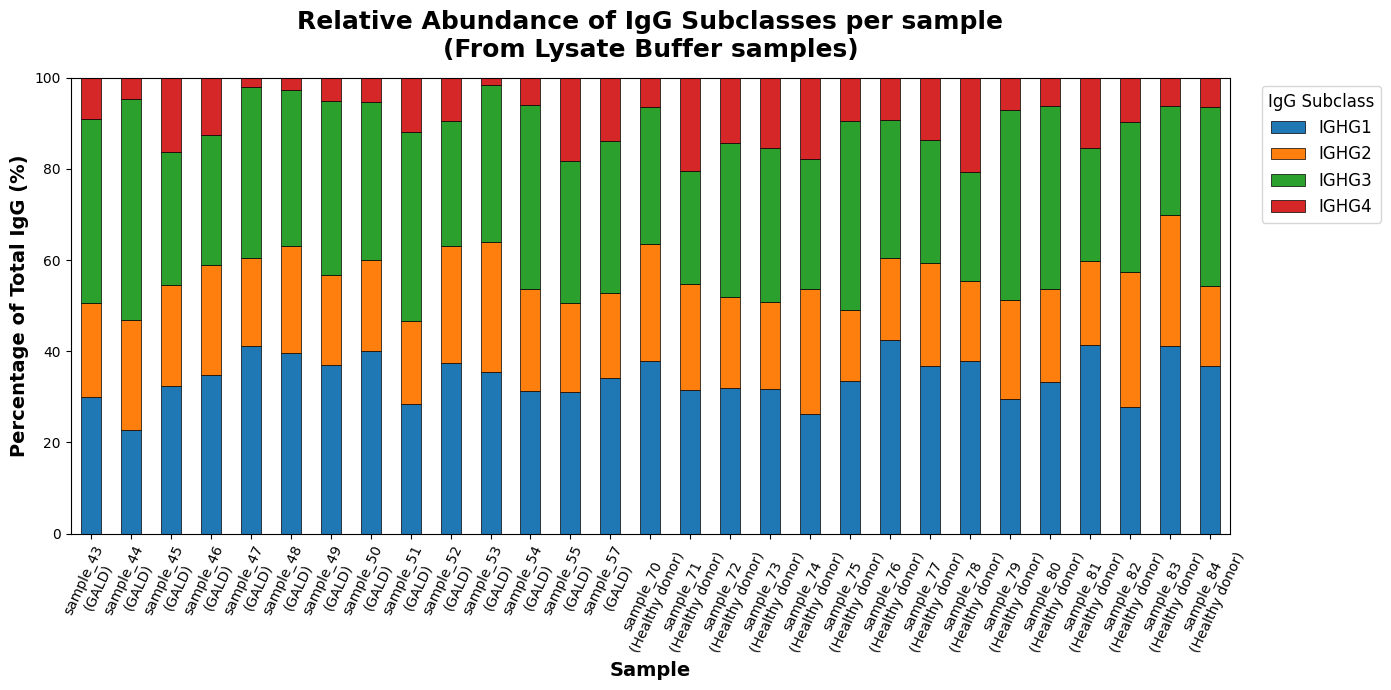


--- Geometric Mean of IgG Subclass Percentages (%) ---


Gene,IGHG1,IGHG2,IGHG3,IGHG4
Group,,,,
GALD,33.61,21.66,35.25,6.65
Healthy donor,34.32,21.28,31.15,10.83


In [24]:
#Stacked barchart of % abundance of IgG subclasses per sample: 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("--- IgG Subclass Relative Abundance Dashboard ---")

# ==========================================
# 1. ISOLATE IgG SUBCLASSES
# ==========================================
# Filter the master protein dataframe for the 4 heavy chains
igg_genes = ["IGHG1", "IGHG2", "IGHG3", "IGHG4"]
igg_df = master_prot_df[master_prot_df["Gene"].isin(igg_genes)].copy()

# Updated to use Razor Intensity
intensity_col = 'Razor Intensity' 

# Pivot the data to get a Matrix of Samples vs Genes
pivot_igg = igg_df.pivot_table(
    index=['Sample', 'Group'], 
    columns='Gene', 
    values=intensity_col, 
    aggfunc='sum'
).fillna(0)

# ==========================================
# 2. CALCULATE PERCENTAGES
# ==========================================
# Divide each row by its sum, then multiply by 100 to get percentages
igg_pct = pivot_igg.div(pivot_igg.sum(axis=1), axis=0) * 100

# Ensure all 4 subclasses are present in the columns
for gene in igg_genes:
    if gene not in igg_pct.columns:
        igg_pct[gene] = 0.0

# Reorder columns explicitly to 1, 2, 3, 4
igg_pct = igg_pct[igg_genes]

# ==========================================
# 3. PLOT 100% STACKED BAR CHART
# ==========================================
# Create a copy for plotting and format the index to show "Sample \n (Group)"
plot_df = igg_pct.copy()
plot_df.index = [f"{sample}\n({group})" for sample, group in plot_df.index]

# Set up a distinct color palette for the 4 subclasses
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 

fig, ax = plt.subplots(figsize=(14, 7))

plot_df.plot(
    kind='bar', 
    stacked=True, 
    color=colors, 
    edgecolor='black',
    linewidth=0.5,
    ax=ax
)

plt.title('Relative Abundance of IgG Subclasses per sample\n(From Lysate Buffer samples)', fontsize=18, weight='bold', pad=15)
plt.ylabel('Percentage of Total IgG (%)', fontsize=14, weight='bold')
plt.xlabel('Sample', fontsize=14, weight='bold')

# Shift the labels to the right by centering them under the rotation
plt.xticks(rotation=65, ha='center', fontsize=10)
plt.ylim(0, 100) 

# Format Legend
plt.legend(title='IgG Subclass', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12, title_fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# 4. CALCULATE & PRINT GEOMETRIC MEANS
# ==========================================
def strict_gmean(x):
    """
    Calculates the geometric mean strictly. 
    Halts the script and raises a ValueError if a 0 is encountered.
    """
    x = np.array(x)
    x = x[~np.isnan(x)] # Drop NaNs safely
    
    if len(x) == 0: 
        return np.nan
        
    # Check for zeroes or negative values
    if np.any(x <= 0):
        raise ValueError("CRITICAL ERROR: Cannot calculate geometric mean because the dataset contains a true '0' value. "
                         "Geometric means require all values to be strictly strictly positive (>0).")
        
    return np.exp(np.mean(np.log(x)))

print("\n--- Geometric Mean of IgG Subclass Percentages (%) ---")

# Apply the strict geometric mean function
gmean_summary = igg_pct.groupby(level='Group').agg(strict_gmean).round(2)

display(gmean_summary)

In [25]:
#CLR transform the % data and perform Welch's T-test between GALD and healthy:

import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

print("--- Statistical Analysis of IgG Subclasses (CLR + Welch's T-test) ---")

# ==========================================
# 1. ISOLATE IgG SUBCLASSES & CALCULATE %
# ==========================================
igg_genes = ["IGHG1", "IGHG2", "IGHG3", "IGHG4"]
igg_df = master_prot_df[master_prot_df["Gene"].isin(igg_genes)].copy()

# Pivot the data 
pivot_igg = igg_df.pivot_table(
    index=['Sample', 'Group'], 
    columns='Gene', 
    values='Razor Intensity', 
    aggfunc='sum'
).fillna(0)

# Calculate percentages
igg_pct = pivot_igg.div(pivot_igg.sum(axis=1), axis=0) * 100

# Ensure all 4 subclasses are present in columns
for gene in igg_genes:
    if gene not in igg_pct.columns:
        igg_pct[gene] = 0.0
igg_pct = igg_pct[igg_genes]

# ==========================================
# 2. CLR TRANSFORMATION
# ==========================================
print("Validating data and performing CLR Transformation...")

# Strict check: If any value is 0 or less, np.log will fail (or return -inf)
if (igg_pct <= 0).any().any():
    raise ValueError("CRITICAL ERROR: A '0' value was detected in the IgG subclass percentages. "
                     "CLR transformation cannot process true zeroes. You must apply a pseudocount first.")

# Calculate row-wise geometric mean
gmeans = np.exp(np.mean(np.log(igg_pct), axis=1))

# Perform CLR: ln( x_i / geometric_mean(x) )
clr_df = np.log(igg_pct.div(gmeans, axis=0))

# ==========================================
# 3. WELCH'S T-TEST & FDR CORRECTION
# ==========================================
print("Running Welch's T-tests...\n")

# Dynamically identify the two groups (e.g., 'GALD' and 'Healthy donor')
groups = clr_df.index.get_level_values('Group').unique()

if len(groups) != 2:
    print(f"Error: Expected exactly 2 groups to compare, but found {len(groups)}: {list(groups)}")
else:
    group1, group2 = groups[0], groups[1]
    results = []
    
    for gene in igg_genes:
        # Extract CLR values for each group
        g1_vals = clr_df.xs(group1, level='Group')[gene]
        g2_vals = clr_df.xs(group2, level='Group')[gene]
        
        # Welch's T-Test (equal_var=False)
        t_stat, p_val = ttest_ind(g1_vals, g2_vals, equal_var=False)
        
        results.append({
            'IgG Subclass': gene,
            f'{group1} Mean (CLR)': round(g1_vals.mean(), 3),
            f'{group2} Mean (CLR)': round(g2_vals.mean(), 3),
            'T-Statistic': round(t_stat, 3),
            'P-Value': p_val
        })
        
    stats_df = pd.DataFrame(results)
    
    # Apply Benjamini-Hochberg FDR correction
    stats_df['FDR (q-value)'] = multipletests(stats_df['P-Value'], method='fdr_bh')[1]
    
    # Format the P-values and FDR for easy reading (scientific notation if very small)
    stats_df['P-Value'] = stats_df['P-Value'].apply(lambda x: f"{x:.4e}" if x < 0.001 else f"{x:.4f}")
    stats_df['FDR (q-value)'] = stats_df['FDR (q-value)'].apply(lambda x: f"{x:.4e}" if x < 0.001 else f"{x:.4f}")
    
    # Highlight significant results
    stats_df['Significant? (q < 0.05)'] = stats_df['FDR (q-value)'].astype(float) < 0.05
    
    display(stats_df)


--- Statistical Analysis of IgG Subclasses (CLR + Welch's T-test) ---
Validating data and performing CLR Transformation...
Running Welch's T-tests...



,IgG Subclass,GALD Mean (CLR),Healthy donor Mean (CLR),T-Statistic,P-Value,FDR (q-value),Significant? (q < 0.05)
0,IGHG1,0.503,0.432,0.847,0.4057,0.4057,False
1,IGHG2,0.064,-0.046,1.325,0.1967,0.2623,False
2,IGHG3,0.551,0.335,2.259,0.0323,0.1102,False
3,IGHG4,-1.117,-0.721,-2.031,0.0551,0.1102,False


## **Part 3 - PCA and volcano plots of CLR transformed data**

In [ ]:
master_pep_df.head(3) 

,Peptide Sequence,Protein,Gene,Sample_Col,Razor Intensity,Sample,Group,Sample_type,Protein Description,Protein_short,Sample_Name
4,AACLLPK,sp|P02768|ALBU_HUMAN,ALB,sample_43 MaxLFQ Intensity,152575.470,sample_43,GALD,Lysate buffer,Albumin,P02768,sample_43 GALD
5,AADDTWEPFASGK,sp|P02766|TTHY_HUMAN,TTR,sample_43 MaxLFQ Intensity,123281.910,sample_43,GALD,Lysate buffer,Transthyretin,P02766,sample_43 GALD
7,AAELIANSLATAGDGLIELR,sp|P35232|PHB1_HUMAN,PHB1,sample_43 MaxLFQ Intensity,56368.457,sample_43,GALD,Lysate buffer,Prohibitin 1,P35232,sample_43 GALD


Making a PCA plot of the CLR transformed and imputed intensity values for the peptide-level. <br>
There is both a version with and without all the proteins NOT related to immunoglobulins. <br>
(There might be maternal antigens that were physically bound to the IgG antibodies in the plasma (and co-eluted). They might actually represent a true biological signature of GALD, potentially making the clustering better. They would have been transfered to the Lysate Buffer assay)

--- Principal Component Analysis: CLR-Transformed Peptide Intensities ---
-> Global Detection Limit (LOD) Pseudocount applied: 312.42

Filtering Immunoglobulin-related peptides...
 -> Total peptides in full dataset: 4413
 -> Total peptides in Immunoglobulin-only dataset: 850

Running Global PCA...
[Entire dataset
(Imputed and CLR] Variance Explained:
   PC1: 26.05%
   PC2: 10.16%



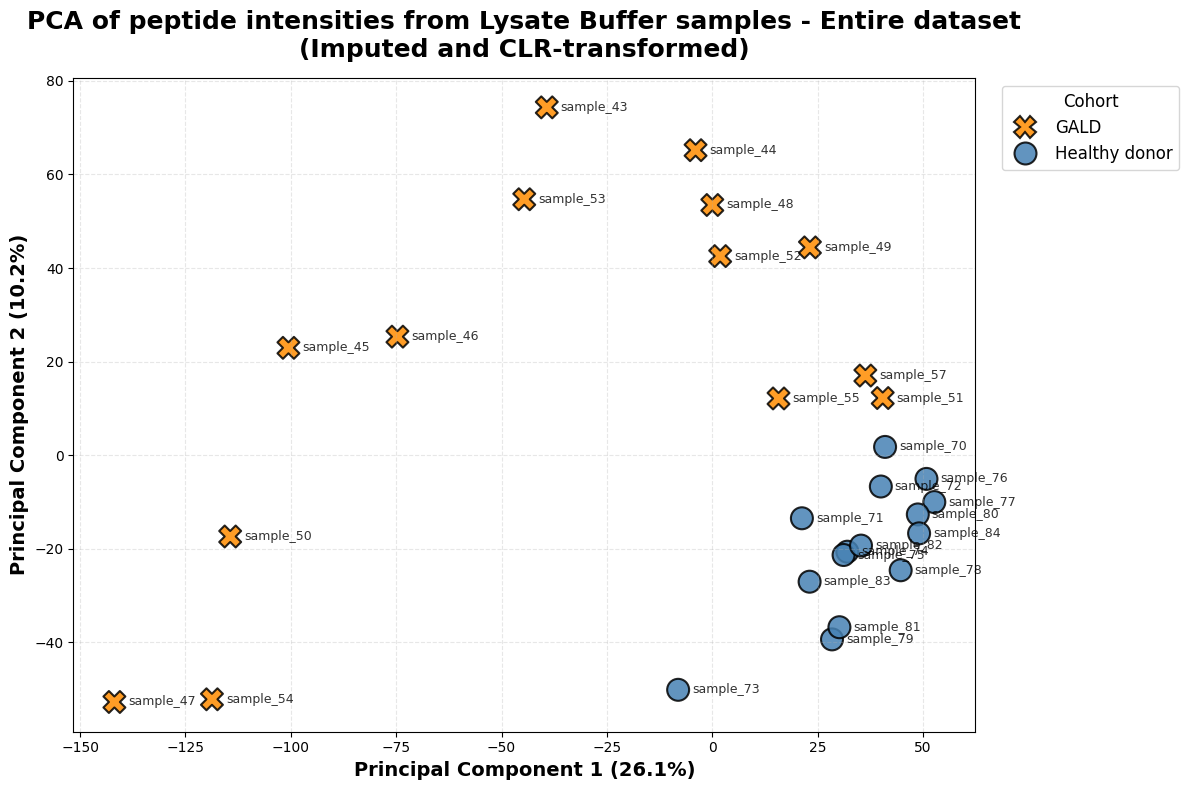

Running Immunoglobulin-Only PCA...
[Immunoglobulin peptides only
(Imputed and CLR] Variance Explained:
   PC1: 16.93%
   PC2: 8.90%



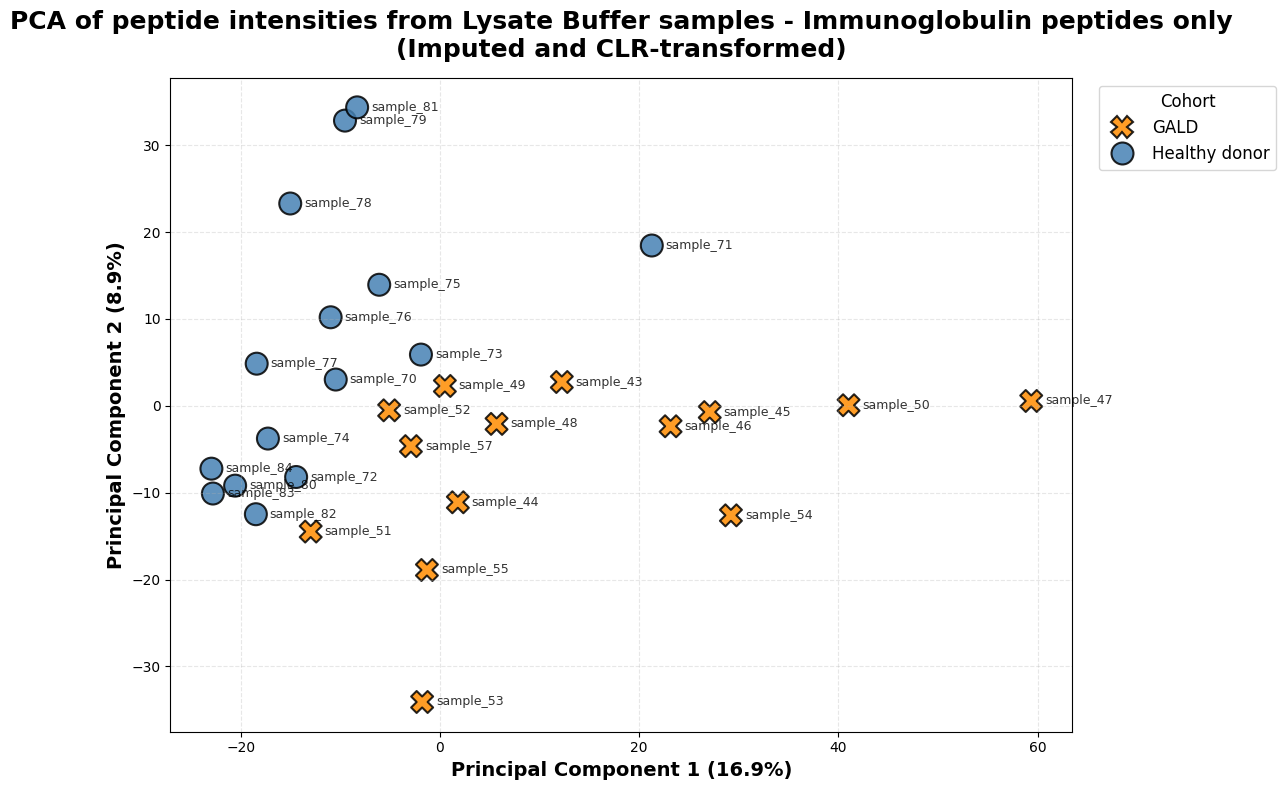

--- Data Extraction Complete ---
You can now use `global_loadings_df` or `ig_loadings_df` to analyze feature importance.


In [ ]:
#PCA plot of CLR-transformed and imputed data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

print("--- Principal Component Analysis: CLR-Transformed Peptide Intensities ---")

# ==========================================
# 1. GLOBAL PSEUDOCOUNT CALCULATION
# ==========================================
intensity_col = 'Razor Intensity' 
feature_col = 'Peptide Sequence' 

# Using the absolute minimum detected intensity across the entire MS run
min_global_int = master_pep_df.loc[master_pep_df[intensity_col] > 0, intensity_col].min()
global_pseudo = min_global_int / 2

print(f"-> Global Detection Limit (LOD) Pseudocount applied: {global_pseudo:.2f}\n")

# ==========================================
# 2. ISOLATE IMMUNOGLOBULINS
# ==========================================
print("Filtering Immunoglobulin-related peptides...")

# Capture based on description or gene name (capturing IGH, IGK, IGL, etc.)

# ig_mask = (
#     master_pep_df["Protein Description"].str.contains("immunoglobulin", case=False, na=False) |
#     master_pep_df["Gene"].str.contains("IG", case=False, na=False) 
# ) 

ig_mask = (
    master_pep_df["Protein Description"].str.contains(r'\bimmunoglobulin\b', case=False, regex=True, na=False) |
    master_pep_df["Gene"].str.contains(r'^IG[HKLJ]', case=False, regex=True, na=False) 
)

# Create the two distinct datasets
ig_pep_df = master_pep_df[ig_mask].copy()
print(f" -> Total peptides in full dataset: {master_pep_df[feature_col].nunique()}")
print(f" -> Total peptides in Immunoglobulin-only dataset: {ig_pep_df[feature_col].nunique()}\n")

# ==========================================
# 3. REUSABLE PCA, PLOTTING & LOADINGS FUNCTION
# ==========================================
def generate_clr_pca(df, title, pseudocount):
    """Pivots data, imputes with LOD, CLR-transforms, plots a 2D PCA, and returns annotated loadings."""
    
    # 1. Pivot to Sample x Feature matrix
    pivot_df = df.pivot_table(
        index=['Sample', 'Group'], 
        columns=feature_col, 
        values=intensity_col, 
        aggfunc='sum'
    ).fillna(0)
    
    if pivot_df.empty or pivot_df.shape[1] < 2:
        print(f"Not enough data to run PCA for: {title}")
        return None
    
    # 2. Impute with global pseudocount (safely eliminates all 0s)
    imputed_df = pivot_df + pseudocount
    
    # 3. CLR Transformation
    gmeans = np.exp(np.mean(np.log(imputed_df), axis=1))
    clr_df = np.log(imputed_df.div(gmeans, axis=0))
    
    # 4. Perform PCA
    pca = PCA(n_components=2)
    pcs = pca.fit_transform(clr_df)
    var_explained = pca.explained_variance_ratio_ * 100
    
    print(f"[{title.split('-')[1].strip() if '-' in title else 'PCA'}] Variance Explained:")
    print(f"   PC1: {var_explained[0]:.2f}%")
    print(f"   PC2: {var_explained[1]:.2f}%\n")
    
    # 5. Extract Loadings and Map Gene IDs
    loadings_df = pd.DataFrame(
        pca.components_.T,
        columns=['PC1_Loading', 'PC2_Loading'],
        index=clr_df.columns
    )
    loadings_df.index.name = feature_col
    
    # Create a mapping dictionary from Peptide Sequence -> Gene
    gene_map = df.drop_duplicates(subset=[feature_col]).set_index(feature_col)['Gene']
    
    # Attach Gene column and reorder so it sits at the front
    loadings_df['Gene'] = loadings_df.index.map(gene_map)
    loadings_df = loadings_df[['Gene', 'PC1_Loading', 'PC2_Loading']]
    
    # Prepare dataframe for Seaborn
    pc_df = pd.DataFrame(data=pcs, columns=['PC1', 'PC2'], index=clr_df.index).reset_index()
    
    # 6. Visualization
    plt.figure(figsize=(12, 8)) 
    ax = sns.scatterplot(
        data=pc_df, 
        x='PC1', 
        y='PC2', 
        hue='Group', 
        style='Group', 
        markers={'GALD': 'X', 'Healthy donor': 'o'}, 
        palette={'GALD': 'darkorange', 'Healthy donor': 'steelblue'},
        s=250,             
        edgecolor='black', 
        linewidth=1.5,
        alpha=0.85
    )
    
    # Add Sample Names to the dots
    for _, row in pc_df.iterrows():
        ax.annotate(
            row['Sample'],
            (row['PC1'], row['PC2']),
            xytext=(10, 0), 
            textcoords='offset points',
            fontsize=9,
            alpha=0.8,
            va='center'
        )
    
    plt.title(title, fontsize=18, weight='bold', pad=15)
    plt.xlabel(f"Principal Component 1 ({var_explained[0]:.1f}%)", fontsize=14, weight='bold')
    plt.ylabel(f"Principal Component 2 ({var_explained[1]:.1f}%)", fontsize=14, weight='bold')
    plt.grid(alpha=0.3, linestyle='--')
    
    plt.legend(title='Cohort', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12, title_fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return loadings_df

# ==========================================
# 4. RUN BOTH PCAs AND CAPTURE LOADINGS
# ==========================================

print("Running Global PCA...")
global_loadings_df = generate_clr_pca(
    df=master_pep_df, 
    title="PCA of peptide intensities from Lysate Buffer samples - Entire dataset\n(Imputed and CLR-transformed)", 
    pseudocount=global_pseudo
)

print("Running Immunoglobulin-Only PCA...")
ig_loadings_df = generate_clr_pca(
    df=ig_pep_df, 
    title="PCA of peptide intensities from Lysate Buffer samples - Immunoglobulin peptides only\n(Imputed and CLR-transformed)", 
    pseudocount=global_pseudo
)

print("--- Data Extraction Complete ---")
print("You can now use `global_loadings_df` or `ig_loadings_df` to analyze feature importance.")


In [28]:
global_loadings_df 

,Gene,PC1_Loading,PC2_Loading
Peptide Sequence,,,
AAAAAAALQAK,RPL4,0.019809,-0.010764
AAATLMSER,SLC4A1,0.001679,-0.006840
AACAQLNDFLQEYGTQGCQV,C4B,-0.013332,-0.016215
AACLLPK,ALB,-0.006699,0.023051
AADDTWEPFASGK,TTR,0.006370,0.009057
...,...,...,...
YYILRPEVMETYMYMWR,MAN1A1,0.009284,0.011788
YYTYLIMNK,C3,-0.003596,-0.012316
YYVDSVK,IGHV3-7,0.006898,0.001639


In [29]:
ig_loadings_df 

,Gene,PC1_Loading,PC2_Loading
Peptide Sequence,,,
AAPSVTLFPPSSEELQANK,IGLC3,0.005262,0.011444
AAPSVTLFPPSSEELQANKATLVCLISDFYPGAVTVAWK,IGLC3,-0.021283,0.023183
AAPSVTLFPPSSEELQANKATLVCLISDFYPGAVTVAWKADSSPVK,IGLC3,-0.044971,0.002808
ADGSPVKAGVETTKPSK,IGLL5,-0.001496,-0.002690
ADGSPVKVGVETTKPSK,IGLC7,0.008408,-0.001892
...,...,...,...
YYADSVK,IGHV3-30,0.007660,0.031506
YYADSVKGR,IGHV3-30,-0.068376,-0.021697
YYADSVKGRFTISR,IGHV3-30,-0.070220,-0.071044


Before showing e.g. top 10 largest positive and negative loading values for the PCA plots, we need some sort of histogram to justify this arbitrary cutoff. 

--- PCA Feature Loadings Distribution Analysis ---


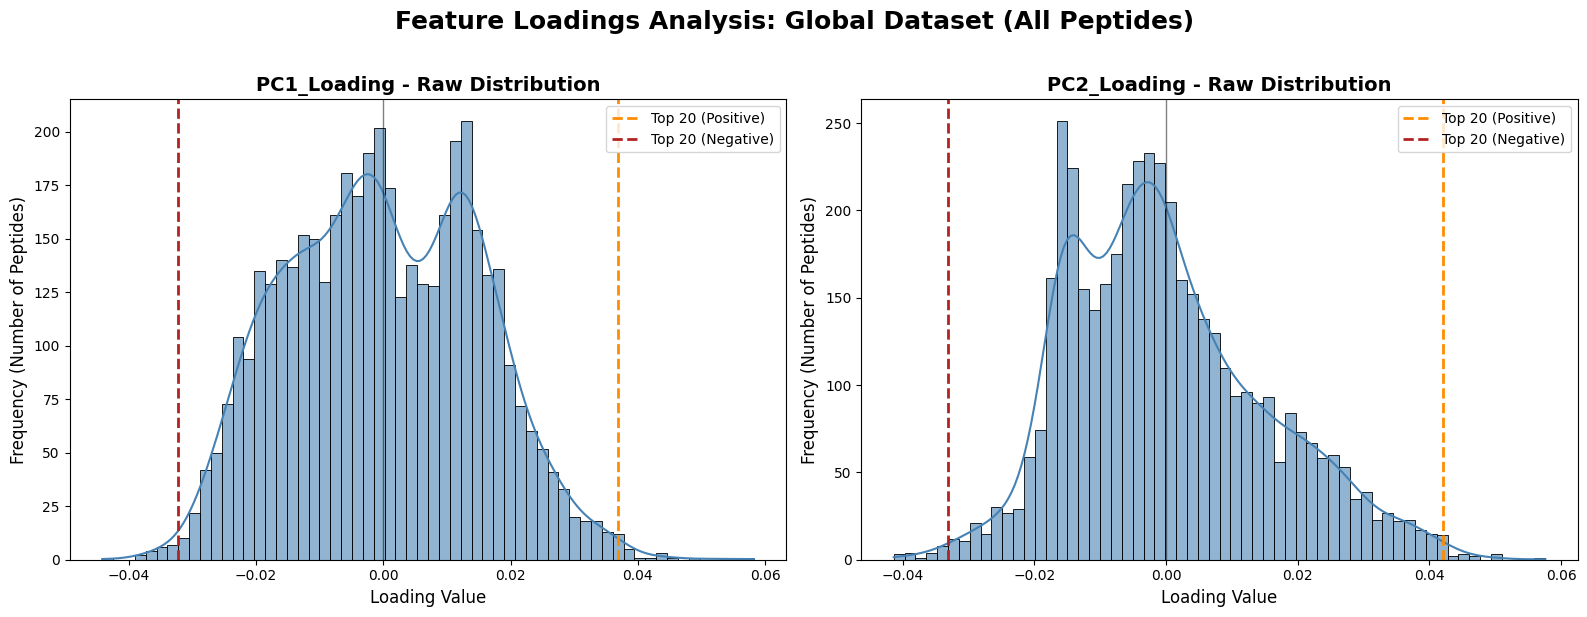

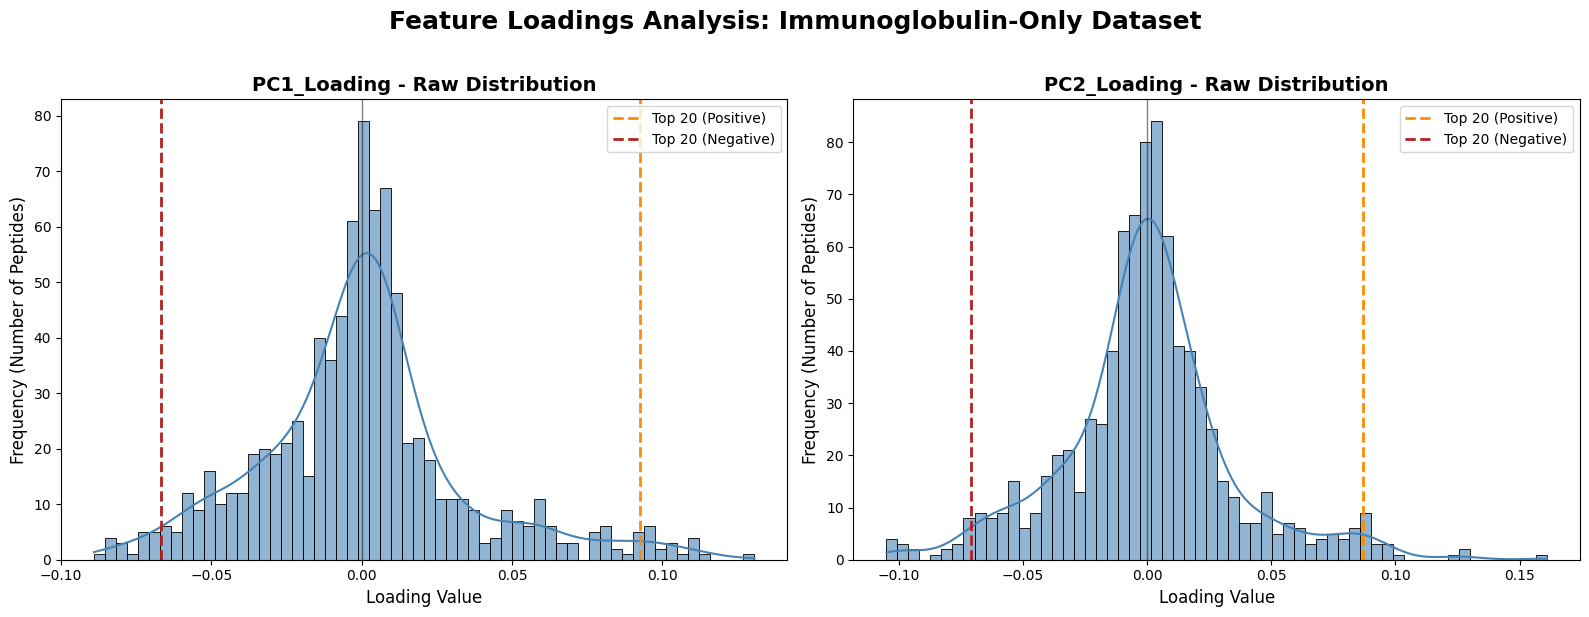

In [40]:
#Histogram of the loading values and their distribution:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- PCA Feature Loadings Distribution Analysis ---")

def analyze_loadings(loadings_df, title_prefix):
    """
    Generates Histogram plots to identify natural cutoffs for PCA loading values.
    """
    if loadings_df is None or loadings_df.empty:
        print(f"No loading data available for {title_prefix}.")
        return

    # Set up a 1x2 grid of plots (Only the Histograms)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"Feature Loadings Analysis: {title_prefix}", fontsize=18, weight='bold', y=1.02)

    for i, pc in enumerate(['PC1_Loading', 'PC2_Loading']):
        
        # ==========================================
        # THE HISTOGRAM (Raw Values)
        # ==========================================
        ax_hist = axes[i]
        sns.histplot(loadings_df[pc], bins=60, kde=True, ax=ax_hist, color='steelblue', edgecolor='black', alpha=0.6)
        
        # Calculate where the top 20 positive and top 20 negative genes start
        top20_pos_threshold = loadings_df[pc].nlargest(20).min()
        top20_neg_threshold = loadings_df[pc].nsmallest(20).max()
        
        ax_hist.axvline(top20_pos_threshold, color='darkorange', linestyle='--', linewidth=2, label='Top 20 (Positive)')
        ax_hist.axvline(top20_neg_threshold, color='firebrick', linestyle='--', linewidth=2, label='Top 20 (Negative)')
        ax_hist.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5) # Center 0 line
        
        ax_hist.set_title(f"{pc} - Raw Distribution", fontsize=14, weight='bold')
        ax_hist.set_xlabel("Loading Value", fontsize=12)
        ax_hist.set_ylabel("Frequency (Number of Peptides)", fontsize=12)
        ax_hist.legend()

    plt.tight_layout()
    plt.show()

# ==========================================
# RUN THE ANALYSIS ON BOTH DATAFRAMES
# ==========================================

# 1. Global Loadings
analyze_loadings(global_loadings_df, "Global Dataset (All Peptides)")

# 2. Immunoglobulin-Only Loadings
analyze_loadings(ig_loadings_df, "Immunoglobulin-Only Dataset")

In [41]:
#Displaying the top 10 absolute largest PCA values: 

import pandas as pd
from IPython.display import display

print("--- PCA Feature Extraction: Top 10 Driving Peptides ---")

def display_top_loadings(loadings_df, dataset_name, top_n=10):
    """
    Extracts and displays the top N features with the highest absolute 
    loading values for both PC1 and PC2.
    """
    if loadings_df is None or loadings_df.empty:
        print(f"No loading data available for {dataset_name}.")
        return
        
    print(f"\n==================================================")
    print(f" TOP {top_n} FEATURES: {dataset_name.upper()}")
    print(f"==================================================")
    
    for pc in ['PC1_Loading', 'PC2_Loading']:
        print(f"\n---> {pc[:3]} (Top {top_n} by Absolute Magnitude)")
        
        # We sort by absolute magnitude to capture extreme positive AND extreme negative drivers
        top_features = loadings_df.assign(
            abs_val=loadings_df[pc].abs()
        ).nlargest(top_n, 'abs_val')[['Gene', pc]]
        
        # Display nicely in the notebook
        display(top_features)

# ==========================================
# RUN EXTRACTION ON BOTH DATAFRAMES
# ==========================================

# 1. Global Loadings
display_top_loadings(global_loadings_df, "Global Dataset")

# 2. Immunoglobulin-Only Loadings
display_top_loadings(ig_loadings_df, "Immunoglobulin-Only Dataset")

--- PCA Feature Extraction: Top 10 Driving Peptides ---

 TOP 10 FEATURES: GLOBAL DATASET

---> PC1 (Top 10 by Absolute Magnitude)


,Gene,PC1_Loading
Peptide Sequence,,
GEEDTGQEEGGSR,HUWE1,0.058246
NPDPWAK,TF,0.053607
AEFAEVSKLVTDLTK,ALB,0.049676
KFICPLTGLWPINTLK,APOH,0.044756
FQGRVTMTR,IGHV1-46,0.044475
ANALASATCERCKGGFAPAEK,LIMS1,-0.044187
LALDLEIATYR,KRT1,0.043927
FTISRDNSKNTLYLQMSSLR,IGHV3-64D,0.042990
GFYPSDISVEWESNGQPENNYKTTPPMLDSDGSFFLYSK,IGHG2,0.041355



---> PC2 (Top 10 by Absolute Magnitude)


,Gene,PC2_Loading
Peptide Sequence,,
LIQFHFHWGSLDGQGSEHTVDK,CA2,0.057623
STMQELNSR,KRT9,0.050041
VTISCTGSSSNIGAGYVVHWYQQLPGTAPK,IGLV1-50,0.049756
LLIYDASSLESGVPSR,IGKV1D-13,0.049739
LVNANGEAVYCK,CAT,0.046252
KNWIQYK,FGG,0.046228
VEPLVTMGQVTALLTSIGWTLPVLPELDDLTVGGLIMGTGIESSSHK,DHCR24,0.045845
TEADAEK,NCL,0.045395
NFTEVHPDYGSHIQALLDKYNAEKPK,CAT,0.044613



 TOP 10 FEATURES: IMMUNOGLOBULIN-ONLY DATASET

---> PC1 (Top 10 by Absolute Magnitude)


,Gene,PC1_Loading
Peptide Sequence,,
VSVFVPPRDGFFGNPR,IGHM,0.130622
NVPLPVIAELPPK,IGHM,0.114008
GLVWVSR,IGHV3-74,0.112195
GLEWMGR,IGHV5-10-1,0.111812
FTCTVTHTDLPSPLK,IGHM,0.111020
DGFFGNPR,IGHM,0.110698
SSEDPNEDIVER,JCHAIN,0.107278
GQPLSPEKYVTSAPMPEPQAPGR,IGHM,0.103233
GQPLSPEK,IGHM,0.102685



---> PC2 (Top 10 by Absolute Magnitude)


,Gene,PC2_Loading
Peptide Sequence,,
ATGIPDR,IGKV3-20,0.160996
DKATFTCFVVGSDLK,IGHD,0.127849
SLWNAGTSVTCTLNHPSLPPQR,IGHD,0.126016
ATFTCFVVGSDLKDAHLTWEVAGKVPTGGVEEGLLER,IGHD,0.122823
LSCAASGFTVSSNEMSWIR,IGHV3-38,-0.104940
AGVETTKPSK,IGLL5,-0.104726
GDGIPDRFSGSSSGAER,IGLV4-69,0.103159
LSLHRPALEDLLLGSEANLTCTLTGLR,IGHA1,-0.102570
ASQGIRNDLGWYQQKPGK,IGKV1-17,-0.100833


**Volcanoplot:**

Using FragPipe output data, we can make a volcanoplot for peptide- and protein level. <br>
We will impute with values below detection limit. <br>
(A presence/absence based imputation might be also be interesting to look into the future. But for now we are just using the fold change. That is because we will always expect most of the peptides/ proteins associated with antibodies to be present in the negative controls, i.e. the lysate buffer samples). 

--- Protein-Level Volcano Plot (FragPipe): Global Pseudocount Addition ---
 -> Global Minimum Protein Intensity: 1471.45
 -> Global Pseudocount (LOD/2) added to ALL values: 735.73

Calculating Log2 Fold Change and Welch's T-tests...
Generating Plot...


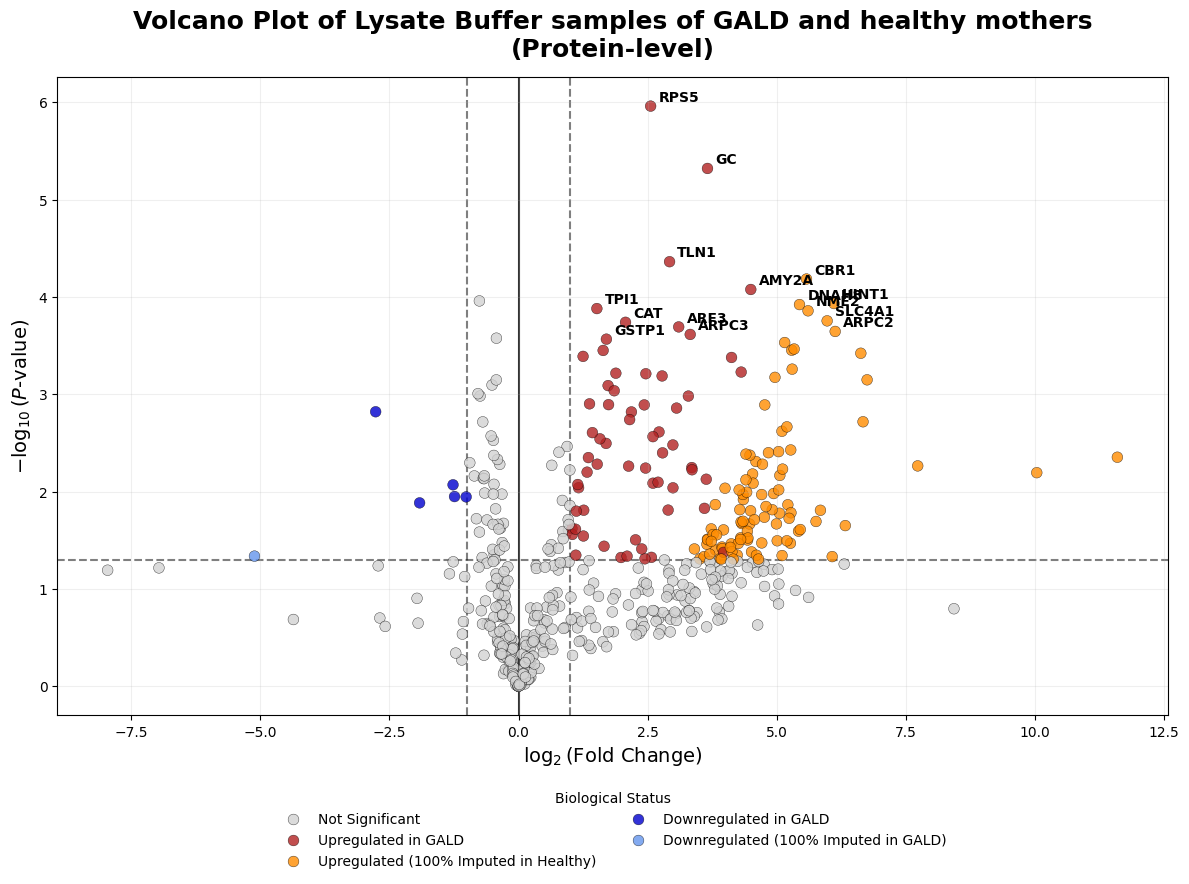


============== SUMMARY ==============
 -> Standard Upregulated: 62
 -> Upregulated (100% Imputed Dropouts): 98
 -> Standard Downregulated: 5
 -> Downregulated (100% Imputed Dropouts): 1


In [ ]:
#Volcano plot of the Lysate buffer samples, protein-level, FragPipe
#Imputing with a pseudocount

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import warnings

print("--- Protein-Level Volcano Plot (FragPipe): Global Pseudocount Addition ---")

# ==========================================
# 1. SETUP & LOD CALCULATION
# ==========================================
feature_col = 'Gene'
# Handle potential column name variations from FragPipe output
intensity_col = 'Razor Intensity' if 'Razor Intensity' in master_prot_df.columns else 'Intensity'

# Find the absolute Limit of Detection (LOD)
min_global_int = master_prot_df.loc[master_prot_df[intensity_col] > 0, intensity_col].min()
lod_pseudo = min_global_int / 2

print(f" -> Global Minimum Protein Intensity: {min_global_int:.2f}")
print(f" -> Global Pseudocount (LOD/2) added to ALL values: {lod_pseudo:.2f}\n")

# ==========================================
# 2. PIVOT DATA & TRACK TRUE DROPOUTS
# ==========================================
pivot_raw = master_prot_df.pivot_table(
    index=['Sample', 'Group'], 
    columns=feature_col, 
    values=intensity_col, 
    aggfunc='sum'
).fillna(0)

# Identify features that are 100% missing in a specific group BEFORE adding pseudocount
gald_raw = pivot_raw.xs('GALD', level='Group')
healthy_raw = pivot_raw.xs('Healthy donor', level='Group')

gald_is_dropout = (gald_raw.max() == 0)
healthy_is_dropout = (healthy_raw.max() == 0)

# ==========================================
# 3. IMPUTATION & STATISTICS
# ==========================================
print("Calculating Log2 Fold Change and Welch's T-tests...")

#Add the pseudocount to EVERYTHING, not just the zeros
imputed_df = pivot_raw + lod_pseudo

gald_imp = imputed_df.xs('GALD', level='Group')
healthy_imp = imputed_df.xs('Healthy donor', level='Group')

# Calculate Log2FC
log2_fc = np.log2(gald_imp.mean() / healthy_imp.mean())

stats_list = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    
    for gene in imputed_df.columns:
        # Skip proteins with zero variance across all samples
        if np.isclose(gald_imp[gene].var(), 0) and np.isclose(healthy_imp[gene].var(), 0):
            continue
            
        stat, p_val = ttest_ind(gald_imp[gene], healthy_imp[gene], equal_var=False)
        
        if not np.isnan(p_val):
            stats_list.append({
                'Gene': gene,
                'Log2FC': log2_fc[gene],
                'P_Value': p_val,
                'Dropout_in_GALD': gald_is_dropout[gene],
                'Dropout_in_Healthy': healthy_is_dropout[gene]
            })

prot_volcano_df = pd.DataFrame(stats_list).dropna()

# FDR Correction and formatting for Y-axis
prot_volcano_df['FDR_Q_Value'] = multipletests(prot_volcano_df['P_Value'], method='fdr_bh')[1]
prot_volcano_df['NegLog10P'] = -np.log10(prot_volcano_df['P_Value'])

# ==========================================
# 4. CATEGORIZE SIGNIFICANCE & DROPOUTS
# ==========================================
p_threshold = 0.05 
fc_threshold = 1.0 # Standard 2-fold change

def categorize_dot(row):
    if row['P_Value'] < p_threshold and row['Log2FC'] > fc_threshold:
        if row['Dropout_in_Healthy']:
            return 'Upregulated (100% Imputed in Healthy)'
        return 'Upregulated in GALD'
        
    elif row['P_Value'] < p_threshold and row['Log2FC'] < -fc_threshold:
        if row['Dropout_in_GALD']:
            return 'Downregulated (100% Imputed in GALD)'
        return 'Downregulated in GALD'
        
    else:
        return 'Not Significant'

prot_volcano_df['Category'] = prot_volcano_df.apply(categorize_dot, axis=1)

# ==========================================
# 5. VISUALIZATION
# ==========================================
print("Generating Plot...")

plt.figure(figsize=(12, 9))

# Custom palette highlighting true dropouts
custom_palette = {
    'Upregulated in GALD': 'firebrick',
    'Upregulated (100% Imputed in Healthy)': 'darkorange', 
    'Downregulated in GALD': 'mediumblue', 
    'Downregulated (100% Imputed in GALD)': 'cornflowerblue', 
    'Not Significant': 'lightgray'
}

sns.scatterplot(
    data=prot_volcano_df, 
    x='Log2FC', 
    y='NegLog10P', 
    hue='Category',
    palette=custom_palette, 
    alpha=0.8, 
    edgecolor='black', 
    linewidth=0.3, 
    s=60 
)

# Threshold lines
plt.axhline(-np.log10(p_threshold), color='black', linestyle='--', alpha=0.5, zorder=0)
plt.axvline(fc_threshold, color='black', linestyle='--', alpha=0.5, zorder=0)
plt.axvline(-fc_threshold, color='black', linestyle='--', alpha=0.5, zorder=0)
plt.axvline(0, color='black', linestyle='-', alpha=0.8, zorder=0)

# Add Labels to Top 15 Proteins
top_hits = prot_volcano_df[prot_volcano_df['Category'] != 'Not Significant'].nlargest(15, 'NegLog10P')
for _, row in top_hits.iterrows():
    plt.text(
        row['Log2FC'] + 0.15, 
        row['NegLog10P'] + 0.05, 
        row['Gene'], 
        fontsize=10, 
        weight='bold', 
        color='black'
    )

# Clean Formatting
plt.title("Volcano Plot of Lysate Buffer samples of GALD and healthy mothers\n(Protein-level)", fontsize=18, weight='bold', pad=15)
plt.xlabel(r"$\log_2(\text{Fold Change})$", fontsize=14, weight='bold')
plt.ylabel(r"$-\log_{10}(P\text{-value})$", fontsize=14, weight='bold')
plt.grid(alpha=0.2)
plt.legend(title="Biological Status", loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

# Print summary
print("\n============== SUMMARY ==============")
print(f" -> Standard Upregulated: {(prot_volcano_df['Category'] == 'Upregulated in GALD').sum()}")
print(f" -> Upregulated (100% Imputed Dropouts): {(prot_volcano_df['Category'] == 'Upregulated (100% Imputed in Healthy)').sum()}")
print(f" -> Standard Downregulated: {(prot_volcano_df['Category'] == 'Downregulated in GALD').sum()}")
print(f" -> Downregulated (100% Imputed Dropouts): {(prot_volcano_df['Category'] == 'Downregulated (100% Imputed in GALD)').sum()}")

In [33]:
#Inspecting underexpressed proteins in GALD
prot_volcano_df[prot_volcano_df["Log2FC"] < -1.0]


,Gene,Log2FC,P_Value,Dropout_in_GALD,Dropout_in_Healthy,FDR_Q_Value,NegLog10P,Category
104,CNNM1,-2.685633,0.198535,True,False,0.295355,0.702163,Not Significant
134,ETFA,-1.086465,0.290692,False,False,0.383120,0.536567,Not Significant
141,FABP5,-1.944119,0.224301,False,False,0.317176,0.649168,Not Significant
231,IGHV1-69D,-1.013765,0.011303,False,False,0.054314,1.946811,Downregulated in GALD
268,IGHV5-10-1,-2.717017,0.057732,False,False,0.130618,1.238586,Not Significant
279,IGKV1-37,-1.915030,0.013018,False,False,0.060939,1.885446,Downregulated in GALD
300,IGKV3D-7,-1.066612,0.215913,False,False,0.307087,0.665722,Not Significant
309,IGLV1-36,-1.267830,0.008490,False,False,0.046568,2.071080,Downregulated in GALD
311,IGLV1-44,-2.766113,0.001508,False,False,0.018262,2.821656,Downregulated in GALD
356,KRT16,-1.263810,0.052513,False,False,0.125158,1.279735,Not Significant


--- Protein-Level Volcano Plot: Immunoglobulins Only (Global Pseudocount) ---
 -> True Global Minimum Intensity: 1471.45
 -> Global Pseudocount (LOD/2) added to ALL values: 735.73
 -> Filtered dataset from 543 total proteins to 130 strict Immunoglobulins.

Calculating Log2 Fold Change and Welch's T-tests...
Generating Plot...


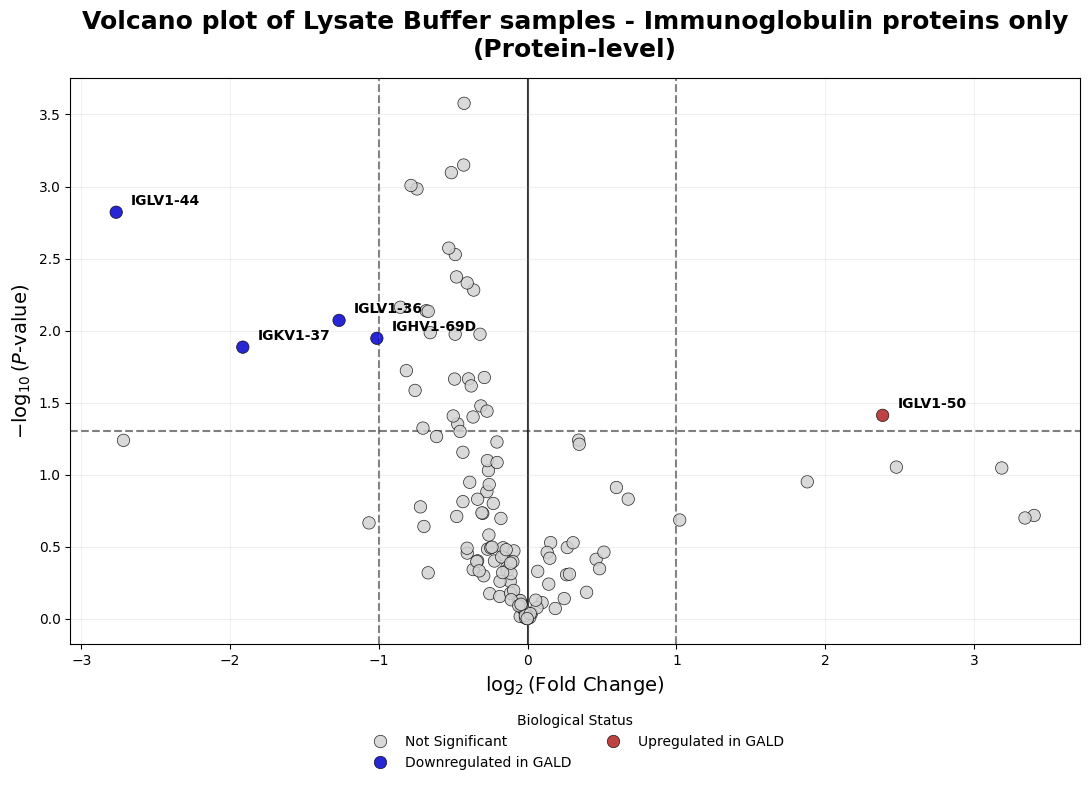


============== SUMMARY (IMMUNOGLOBULINS ONLY) ==============
 -> Standard Upregulated: 1
 -> Upregulated (100% Imputed Dropouts): 0
 -> Standard Downregulated: 4
 -> Downregulated (100% Imputed Dropouts): 0


In [ ]:
#Volcano plot of the Lysate buffer samples, protein-level, FragPipe
#ONLY the immunoglobulin proteins
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import warnings

print("--- Protein-Level Volcano Plot: Immunoglobulins Only (Global Pseudocount) ---")

# ==========================================
# 1. SETUP & GLOBAL LOD CALCULATION
# ==========================================
feature_col = 'Gene'
intensity_col = 'Razor Intensity' if 'Razor Intensity' in master_prot_df.columns else 'Intensity'

# Calculate LOD from the ENTIRE dataset
min_global_int = master_prot_df.loc[master_prot_df[intensity_col] > 0, intensity_col].min()
lod_pseudo = min_global_int / 2

print(f" -> True Global Minimum Intensity: {min_global_int:.2f}")
print(f" -> Global Pseudocount (LOD/2) added to ALL values: {lod_pseudo:.2f}")

# ==========================================
# 2. ISOLATE IMMUNOGLOBULINS (STRICT REGEX)
# ==========================================
# Strict filter: 
# 1. Description contains the standalone word "immunoglobulin" OR
# 2. Gene name STARTS with IGH, IGK, IGL, or IGJ.
ig_mask = (
    master_prot_df["Protein Description"].str.contains(r'\bimmunoglobulin\b', case=False, regex=True, na=False) |
    master_prot_df["Gene"].str.contains(r'^IG[HKLJ]', case=False, regex=True, na=False) 
)

ig_prot_df = master_prot_df[ig_mask].copy()

print(f" -> Filtered dataset from {master_prot_df[feature_col].nunique()} total proteins to {ig_prot_df[feature_col].nunique()} strict Immunoglobulins.\n")

# ==========================================
# 3. PIVOT DATA & TRACK TRUE DROPOUTS
# ==========================================
pivot_raw = ig_prot_df.pivot_table(
    index=['Sample', 'Group'], 
    columns=feature_col, 
    values=intensity_col, 
    aggfunc='sum'
).fillna(0)

# Identify features that are 100% missing in a specific group BEFORE adding pseudocount
gald_raw = pivot_raw.xs('GALD', level='Group')
healthy_raw = pivot_raw.xs('Healthy donor', level='Group')

gald_is_dropout = (gald_raw.max() == 0)
healthy_is_dropout = (healthy_raw.max() == 0)

# ==========================================
# 4. IMPUTATION & STATISTICS
# ==========================================
print("Calculating Log2 Fold Change and Welch's T-tests...")

#Add the pseudocount to EVERYTHING, not just the zeros
imputed_df = pivot_raw + lod_pseudo

gald_imp = imputed_df.xs('GALD', level='Group')
healthy_imp = imputed_df.xs('Healthy donor', level='Group')

# Calculate Log2FC
log2_fc = np.log2(gald_imp.mean() / healthy_imp.mean())

stats_list = []

# Suppress the harmless Scipy 'Catastrophic Cancellation' precision warning 
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    
    for gene in imputed_df.columns:
        # Safely check if the variance is effectively zero in BOTH groups
        if np.isclose(gald_imp[gene].var(), 0) and np.isclose(healthy_imp[gene].var(), 0):
            continue
            
        stat, p_val = ttest_ind(gald_imp[gene], healthy_imp[gene], equal_var=False)
        
        # Only keep valid p-values (ttest_ind returns NaN if math completely fails)
        if not np.isnan(p_val):
            stats_list.append({
                'Gene': gene,
                'Log2FC': log2_fc[gene],
                'P_Value': p_val,
                'Dropout_in_GALD': gald_is_dropout[gene],
                'Dropout_in_Healthy': healthy_is_dropout[gene]
            })

ig_volcano_df = pd.DataFrame(stats_list)

if not ig_volcano_df.empty:
    # FDR Correction and formatting for Y-axis
    ig_volcano_df['FDR_Q_Value'] = multipletests(ig_volcano_df['P_Value'], method='fdr_bh')[1]
    ig_volcano_df['NegLog10P'] = -np.log10(ig_volcano_df['P_Value'])

    # ==========================================
    # 5. CATEGORIZE SIGNIFICANCE & DROPOUTS
    # ==========================================
    p_threshold = 0.05 
    fc_threshold = 1.0 # Standard 2-fold change

    def categorize_dot(row):
        if row['P_Value'] < p_threshold and row['Log2FC'] > fc_threshold:
            if row['Dropout_in_Healthy']:
                return 'Upregulated (100% Imputed in Healthy)'
            return 'Upregulated in GALD'
            
        elif row['P_Value'] < p_threshold and row['Log2FC'] < -fc_threshold:
            if row['Dropout_in_GALD']:
                return 'Downregulated (100% Imputed in GALD)'
            return 'Downregulated in GALD'
            
        else:
            return 'Not Significant'

    ig_volcano_df['Category'] = ig_volcano_df.apply(categorize_dot, axis=1)

    # ==========================================
    # 6. VISUALIZATION
    # ==========================================
    print("Generating Plot...")

    plt.figure(figsize=(11, 8))

    custom_palette = {
        'Upregulated in GALD': 'firebrick',
        'Upregulated (100% Imputed in Healthy)': 'darkorange', 
        'Downregulated in GALD': 'mediumblue', 
        'Downregulated (100% Imputed in GALD)': 'cornflowerblue', 
        'Not Significant': 'lightgray'
    }

    sns.scatterplot(
        data=ig_volcano_df, 
        x='Log2FC', 
        y='NegLog10P', 
        hue='Category',
        palette=custom_palette, 
        alpha=0.85, 
        edgecolor='black', 
        linewidth=0.5, 
        s=80 
    )

    # Threshold lines
    plt.axhline(-np.log10(p_threshold), color='black', linestyle='--', alpha=0.5, zorder=0)
    plt.axvline(fc_threshold, color='black', linestyle='--', alpha=0.5, zorder=0)
    plt.axvline(-fc_threshold, color='black', linestyle='--', alpha=0.5, zorder=0)
    plt.axvline(0, color='black', linestyle='-', alpha=0.8, zorder=0)

    # Add Labels to ALL Significant Ig Proteins
    sig_hits = ig_volcano_df[ig_volcano_df['Category'] != 'Not Significant']
    for _, row in sig_hits.iterrows():
        plt.text(
            row['Log2FC'] + 0.1, 
            row['NegLog10P'] + 0.05, 
            row['Gene'], 
            fontsize=10, 
            weight='bold', 
            color='black'
        )

    plt.title("Volcano plot of Lysate Buffer samples - Immunoglobulin proteins only\n(Protein-level)", fontsize=18, weight='bold', pad=15)
    plt.xlabel(r"$\log_2(\text{Fold Change})$", fontsize=14, weight='bold')
    plt.ylabel(r"$-\log_{10}(P\text{-value})$", fontsize=14, weight='bold')
    plt.grid(alpha=0.2)
    plt.legend(title="Biological Status", loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False)
    plt.tight_layout()
    plt.show()

    # Print summary
    print("\n============== SUMMARY (IMMUNOGLOBULINS ONLY) ==============")
    print(f" -> Standard Upregulated: {(ig_volcano_df['Category'] == 'Upregulated in GALD').sum()}")
    print(f" -> Upregulated (100% Imputed Dropouts): {(ig_volcano_df['Category'] == 'Upregulated (100% Imputed in Healthy)').sum()}")
    print(f" -> Standard Downregulated: {(ig_volcano_df['Category'] == 'Downregulated in GALD').sum()}")
    print(f" -> Downregulated (100% Imputed Dropouts): {(ig_volcano_df['Category'] == 'Downregulated (100% Imputed in GALD)').sum()}")
else:
    print("Error: No proteins survived the statistical thresholds to plot.")


**In conclusion:** <br>

1) No indications of altered Fc region glycosylation in IgG of GALD mothers, years (?) after pregnancy
2) No shifted IgG subclass distribution in GALD mothers
3) Seemingly distinguishable proteomic profile between cohorts in Lysate buffer sample. There is also a structural difference in the preference for certain IgG variable region genes in GALD and non-GALD. 